In [1]:
!pip -q install kagglehub timm==1.0.11 lightgbm iterative-stratification pyarrow open_clip_torch --upgrade
!pip -q install scikit-learn pandas matplotlib tqdm pillow scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 115.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00


In [2]:
import os, gc, json, math, random, re, warnings, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
                                                                                  
                                                                              
import logging
logging.getLogger('py.warnings').setLevel(logging.ERROR)

class CFG:
    seed = 42

                      
    dataset  = 'daniilantonov5/3d-mesh-quality-control'
    work     = Path('/content/work'); work.mkdir(parents=True, exist_ok=True)
    cache    = work / 'cache';        cache.mkdir(parents=True, exist_ok=True)

                                 
                                                                                          
                                                                                
    view_mode = 'multiview'                           
    tile      = 448                                                      
                                                                                                    
    grid_rows, grid_cols = 2, 3

                   
                                                                                             
                                                                                         
                                                                                         
    backbone   = 'vit_small_patch14_reg4_dinov2.lvd142m'                                                              
                                                                                               
                                                                                           
    backbone_lr = 4e-5                                                                            
    layer_decay = 0.75                                                                   
    drop_rate  = 0.2
    epochs     = 16                    
    batch_size = 6                                              
    mixup      = 0.4                                                                    

                                                  
    use_clip   = True                                                                       
    clip_model = ('ViT-B-32', 'laion2b_s34b_b79k')
    use_dino_frozen = True                                                                   
    dino_frozen_model = 'vit_base_patch14_reg4_dinov2.lvd142m'
    dino_pca   = 128
    lr         = 3e-4
    head_lr_mult = 10.0
    weight_decay = 0.05
    warmup_frac  = 0.1
    label_smooth = 0.01
    amp        = True
    num_workers = 4

                  
    n_folds = 5
    RUN_ALL_FOLDS = True                                                        
    folds_to_run  = [0]

                        
    tta = 2                                                                           
    n_snapshots = 3                                                                         
    run_tag = 'dino448_s2'                                               
                                                                                             
    ensemble_tags = ['dino448_v2', 'dino448_s2', 'cnx288_v4', 'cnx288_v5', 'dino448', 'dinos224']                                       
                                                                                                 
                                                                                             
    rebuild_specs = {'dino448': ('vit_small_patch14_reg4_dinov2.lvd142m', 448, 'multiview')}
    ensemble_select = True                                                                          
    level2_seeds = 3                                                                        
    ema_decay = 0.999                                                                                      
    model_seed = 1                                                                                       
    level2_all_candidates = True                                                                         
    ensemble_weights = True                                                                            
    postproc_select = True                                                                       
    level2_member_inputs = True                                                                 
                                                                                                  
    rule_select_by_nested = True                                                             
    use_geo_branch = True                                                                       
                                                                                    

                                           
    use_drive   = True                                                                                    
    drive_dir   = '/content/drive/MyDrive/sber_meshqc'
    resume      = True                                                            
    ckpt_every  = 1                                                  
    ckpt_fp16   = True                                                             
    keep_fold_ckpt = False                                                             
    force_recompute = []                                                                      

                     
    artifact_cols = ['abstract','artifacts','intersection','lowpoly','noisy',
                     'open','partial','scale','set','simple']
    target_cols   = artifact_cols + ['quality']
    n_targets     = 11

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

                                                                                          
                                                                                         
                                                                                        
if CFG.use_drive and Path(CFG.drive_dir).parent.exists():
    CFG.work = Path(CFG.drive_dir); CFG.work.mkdir(parents=True, exist_ok=True)
    CFG.cache = CFG.work / 'cache'; CFG.cache.mkdir(parents=True, exist_ok=True)

if CFG.RUN_ALL_FOLDS:
    CFG.folds_to_run = list(range(CFG.n_folds))

def seed_everything(seed=CFG.seed):
    random.seed(seed); np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False                                                     
    torch.backends.cudnn.benchmark = True

seed_everything()
print('device:', CFG.device, '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')

IS_VIT = any(k in CFG.backbone for k in ('vit_', 'dinov2', 'deit', 'eva'))
if IS_VIT:
                                                                                        
                                                                                       
    if CFG.view_mode != 'multiview':
        print('ViT-бэкбон -> view_mode переключён на multiview')
        CFG.view_mode = 'multiview'
    patch = 14 if 'patch14' in CFG.backbone else (16 if 'patch16' in CFG.backbone else 8)
    if CFG.tile % patch:
        CFG.tile = int(round(CFG.tile / patch) * patch)
        print(f'tile округлён до кратного патчу {patch}: {CFG.tile}')
    print(f'{CFG.backbone}: {CFG.tile // patch}x{CFG.tile // patch} патчей на вид, 6 видов')
print('view_mode:', CFG.view_mode, '| tile:', CFG.tile, '| run_tag:', CFG.run_tag)

device: cuda | NVIDIA A100-SXM4-80GB
vit_small_patch14_reg4_dinov2.lvd142m: 32x32 патчей на вид, 6 видов
view_mode: multiview | tile: 448 | run_tag: dino448_s2


In [3]:
import joblib, zipfile, time

if CFG.use_drive:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        CFG.work = Path(CFG.drive_dir)
    except Exception as e:
        print('Drive недоступен, работаем в /content/work — прогресс исчезнет при перезапуске:', e)
CFG.work.mkdir(parents=True, exist_ok=True)
CFG.cache = CFG.work / 'cache'; CFG.cache.mkdir(parents=True, exist_ok=True)
ART  = CFG.work / 'artifacts'; ART.mkdir(parents=True, exist_ok=True)
CKPT = CFG.work / 'ckpt';      CKPT.mkdir(parents=True, exist_ok=True)
LOG_CSV = CFG.work / 'training_log.csv'
print('рабочая директория:', CFG.work)

def _atomic(path, writer):
    """Пишем во временный файл рядом и подменяем: обрыв не испортит существующий артефакт."""
    path = Path(path)
    tmp = path.with_suffix(path.suffix + '.tmp')
    writer(tmp)
    os.replace(tmp, path)

def art_path(name):
    return ART / f'{name}.joblib'

def rt(name):
    """Имя артефакта, привязанное к конфигурации прогона (run_tag)."""
    return f'{CFG.run_tag}_{name}'

def has_artifact(name):
    return art_path(name).exists() and name not in CFG.force_recompute

def save_artifact(name, obj, compress=3):
    _atomic(art_path(name), lambda p: joblib.dump(obj, p, compress=compress))
    return obj

def load_artifact(name):
    return joblib.load(art_path(name))

def cached(name, fn, compress=3):
    """Единая точка «проверить существование -> иначе посчитать и сохранить»."""
    if CFG.resume and has_artifact(name):
        obj = load_artifact(name)
        print(f'  [кэш] {name}: загружено')
        return obj
    t0 = time.time()
    obj = fn()
    save_artifact(name, obj, compress=compress)
    print(f'  [новое] {name}: посчитано за {time.time() - t0:.0f} c')
    return obj

                                                                                    
def rng_state():
    st = {'py': random.getstate(), 'np': np.random.get_state(), 'torch': torch.get_rng_state()}
    if torch.cuda.is_available():
        st['cuda'] = torch.cuda.get_rng_state_all()
    return st

def set_rng_state(st):
    try:
        random.setstate(st['py']); np.random.set_state(st['np'])
        torch.set_rng_state(st['torch'].cpu() if torch.is_tensor(st['torch']) else st['torch'])
        if 'cuda' in st and torch.cuda.is_available():
            torch.cuda.set_rng_state_all([s.cpu() if torch.is_tensor(s) else s for s in st['cuda']])
    except Exception as e:
        print('  не удалось восстановить состояние ГСЧ (продолжаем с текущим):', e)

                                   
def _to_fp16(sd):
    return {k: (v.half() if torch.is_tensor(v) and v.is_floating_point() else v)
            for k, v in sd.items()}

def _to_fp32(sd):
    return {k: (v.float() if torch.is_tensor(v) and v.is_floating_point() else v)
            for k, v in sd.items()}

def save_ckpt(fold, payload):
    _atomic(CKPT / f'{CFG.run_tag}_fold{fold}.pt', lambda p: torch.save(payload, p))

def run_cfg():
    """Сигнатура прогона. Чекпоинт и сохранённые предсказания годятся только при её совпадении:
    один и тот же run_tag мог использоваться в прошлой версии ноутбука с другой архитектурой,
    разрешением или набором признаков — и тогда старое состояние молча портит новый прогон."""
                                                                                        
                                                      
    return {'tile': CFG.tile, 'backbone': CFG.backbone, 'view_mode': CFG.view_mode,
            'epochs': CFG.epochs, 'feat_ver': globals().get('FEAT_VER', '?'),
            'n_feats': len(globals().get('FEAT_COLS', [])),
            'geo': bool(getattr(CFG, 'use_geo_branch', True)),
            'ema': float(getattr(CFG, 'ema_decay', 0.0)),
            'model_seed': int(getattr(CFG, 'model_seed', 0))}

def _cfg_mismatch(saved):
    """Сравниваются только поля, записанные и в артефакте, и в текущей конфигурации.
    Артефакты старых версий ноутбука (без cfg или с неполным набором полей) принимаются
    с предупреждением: считать их несовместимыми значило бы молча переобучать готовые
    фолды часами. Смена бэкбона, tile или режима видов по-прежнему ловится."""
    cur = run_cfg()
    if not saved:
        print('  [!] у артефакта не записана конфигурация (старая версия ноутбука) — принимаю как есть')
        return []
    return [f'{k}: было {saved[k]!r}, стало {cur[k]!r}' for k in cur if k in saved and saved[k] != cur[k]]

def load_ckpt(fold):
    p = CKPT / f'{CFG.run_tag}_fold{fold}.pt'
    if not (CFG.resume and p.exists()):
        return None
    try:
        ck = torch.load(p, map_location='cpu', weights_only=False)
    except Exception as e:
        print(f'  чекпоинт фолда {fold} не читается ({e}), начинаем фолд заново')
        return None
    diff = _cfg_mismatch(ck.get('cfg'))
    if diff:
        print(f'  !! чекпоинт фолда {fold} от ДРУГОЙ конфигурации, игнорирую его:')
        for d in diff:
            print('     -', d)
        print(f'     (файл {p.name} остаётся на диске; смените CFG.run_tag, чтобы прогоны не пересекались)')
        return None
    return ck

def drop_ckpt(fold):
    p = CKPT / f'{CFG.run_tag}_fold{fold}.pt'
    if p.exists() and not CFG.keep_fold_ckpt:
        p.unlink()

def log_epoch(row):
    """Дописываемый лог: переживает обрывы, нужен для отчёта об экспериментах."""
    df = pd.DataFrame([row])
    header = not LOG_CSV.exists()
    df.to_csv(LOG_CSV, mode='a', header=header, index=False)

done_folds = sorted(p.stem for p in ART.glob(f'{CFG.run_tag}_fold*_preds.joblib'))
print('уже посчитанные фолды:', done_folds if done_folds else 'нет')
print('незавершённые чекпоинты:', [p.name for p in CKPT.glob('fold*.pt')] or 'нет')

Mounted at /content/drive
рабочая директория: /content/drive/MyDrive/sber_meshqc
уже посчитанные фолды: нет
незавершённые чекпоинты: нет


In [4]:
def _family(backbone):
    b = backbone.lower()
    if any(k in b for k in ('vit', 'dinov2', 'deit', 'eva')):
        return 'vit'
    for fam in ('convnext', 'efficientnet', 'resnet'):
        if fam in b:
            return fam
    return b.split('.')[0]

_fam = _family(CFG.backbone)
for key, fam in {'cnx': 'convnext', 'convnext': 'convnext', 'dino': 'vit', 'vit': 'vit',
                 'eff': 'efficientnet'}.items():
    if key in CFG.run_tag.lower() and fam != _fam:
        print(f'!! run_tag «{CFG.run_tag}» намекает на {fam}, а CFG.backbone = {CFG.backbone} ({_fam})')
        break
for tag in CFG.ensemble_tags:
    if tag == CFG.run_tag or not art_path(f'{tag}_fold0_preds').exists():
        continue
    try:
        cfg = load_artifact(f'{tag}_fold0_preds').get('cfg') or {}
    except Exception:
        cfg = {}
    keys = [k for k in ('backbone', 'tile', 'view_mode') if k in cfg]
    if keys and all(cfg[k] == getattr(CFG, k) for k in keys):
        print(f'!! прогон совпадает с членом ансамбля «{tag}» по {keys} — разнообразия не будет')
print(f'прогон {CFG.run_tag}: {CFG.backbone} ({_fam}), tile={CFG.tile}, {CFG.view_mode}, '
      f'гео-ветка: {"да" if getattr(CFG, "use_geo_branch", True) else "нет"}')

!! прогон совпадает с членом ансамбля «dino448_v2» по ['backbone', 'tile', 'view_mode'] — разнообразия не будет
!! прогон совпадает с членом ансамбля «dino448» по ['backbone', 'tile', 'view_mode'] — разнообразия не будет
прогон dino448_s2: vit_small_patch14_reg4_dinov2.lvd142m (vit), tile=448, multiview, гео-ветка: да


In [5]:
import kagglehub

root = Path(kagglehub.dataset_download(CFG.dataset))
print('dataset root:', root)

def _pick_dir(mode):
    """Папка с максимальным числом .npz, в пути которой встречается train/test."""
    best, best_n = None, -1
    for p in root.rglob('*'):
        if not p.is_dir():
            continue
        if mode not in str(p).lower():
            continue
        n = sum(1 for _ in p.glob('*.npz'))
        if n > best_n:
            best, best_n = p, n
    if best is None or best_n == 0:
        raise FileNotFoundError(f'не найдена папка с .npz для {mode}')
    return best

def _pick_csv(mode):
    cands = list(root.rglob('*.csv'))
    def score(p):
        n = p.name.lower(); s = 0
        if mode == 'train':
            s += 10 * ('train' in n) - 20 * ('submission' in n) - 20 * ('test' in n)
        else:
            s += 10 * ('test' in n) - 5 * ('submission' in n) - 20 * ('train' in n)
        return s - 0.001 * len(n)
    return sorted(cands, key=score, reverse=True)[0]

TRAIN_DIR, TEST_DIR = _pick_dir('train'), _pick_dir('test')
TRAIN_CSV, TEST_CSV = _pick_csv('train'), _pick_csv('test')
print('train dir :', TRAIN_DIR, len(list(TRAIN_DIR.glob('*.npz'))), 'npz /',
      len(list(TRAIN_DIR.glob('*.png'))), 'png')
print('test  dir :', TEST_DIR,  len(list(TEST_DIR.glob('*.npz'))),  'npz /',
      len(list(TEST_DIR.glob('*.png'))),  'png')
print('train csv :', TRAIN_CSV)
print('test  csv :', TEST_CSV)

train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)[['item_id']].copy()
train_df['item_id'] = train_df['item_id'].astype(str)
test_df['item_id']  = test_df['item_id'].astype(str)

if 'quality' not in train_df.columns:
    train_df['quality'] = (train_df[CFG.artifact_cols].sum(1) == 0).astype(int)

print(train_df.shape, test_df.shape)
train_df.head()

Using Colab cache for faster access to the '3d-mesh-quality-control' dataset.
dataset root: /kaggle/input/3d-mesh-quality-control
train dir : /kaggle/input/3d-mesh-quality-control/train (2)/train 8964 npz / 8964 png
test  dir : /kaggle/input/3d-mesh-quality-control/test (1)/test 669 npz / 669 png
train csv : /kaggle/input/3d-mesh-quality-control/train.csv
test  csv : /kaggle/input/3d-mesh-quality-control/test (1).csv
(8964, 12) (669, 1)


,item_id,abstract,artifacts,intersection,lowpoly,noisy,open,partial,scale,set,simple,quality
0,0001be62-bf9c-4c15-8a09-dce209be9715,0,1,0,0,0,0,0,0,0,0,0
1,000ad3b9-75cf-4b8f-9786-de63f9a8ffa8,0,0,0,0,0,0,0,0,0,1,0
2,0012e069-5caf-44fd-85e4-9a38f6eefd2e,0,0,0,0,0,0,0,0,0,1,0
3,0024dc8f-a2d7-4556-94dc-6b4b0f46ca0d,1,0,0,1,0,0,0,0,0,0,0
4,002b097b-4237-4610-952c-6095d48fb7a0,0,0,0,0,0,0,0,0,0,1,0


In [6]:
n = len(train_df)
prev = train_df[CFG.target_cols].mean()
derived = (train_df[CFG.artifact_cols].sum(1) == 0).astype(int)
print('quality == (no defects) для всех строк:', bool((derived == train_df['quality']).all()))
print('объектов:', n)

sup = train_df[CFG.artifact_cols].sum()
w   = sup / sup.sum()
eda = pd.DataFrame({'prevalence': prev[CFG.artifact_cols].round(4),
                    'support': sup,
                    'weight_in_metric': w.round(4),
                    'max_points': (10 * w).round(3)}).sort_values('weight_in_metric', ascending=False)
display(eda)
print('\n>>> Вывод: noisy+simple+abstract+lowpoly = %.1f%% веса второй половины метрики.'
      % (100 * w[['noisy','simple','abstract','lowpoly']].sum()))
print('>>> intersection и scale вместе стоят < %.2f балла — их не надо вылизывать.'
      % (10 * w[['intersection','scale']].sum()))

quality == (no defects) для всех строк: True
объектов: 8964


,prevalence,support,weight_in_metric,max_points
noisy,0.2844,2549,0.2746,2.746
simple,0.2152,1929,0.2078,2.078
abstract,0.1332,1194,0.1286,1.286
lowpoly,0.1235,1107,0.1192,1.192
set,0.1044,936,0.1008,1.008
open,0.0607,544,0.0586,0.586
artifacts,0.0485,435,0.0469,0.469
partial,0.0419,376,0.0405,0.405
intersection,0.0119,107,0.0115,0.115
scale,0.0119,107,0.0115,0.115



>>> Вывод: noisy+simple+abstract+lowpoly = 73.0% веса второй половины метрики.
>>> intersection и scale вместе стоят < 0.23 балла — их не надо вылизывать.


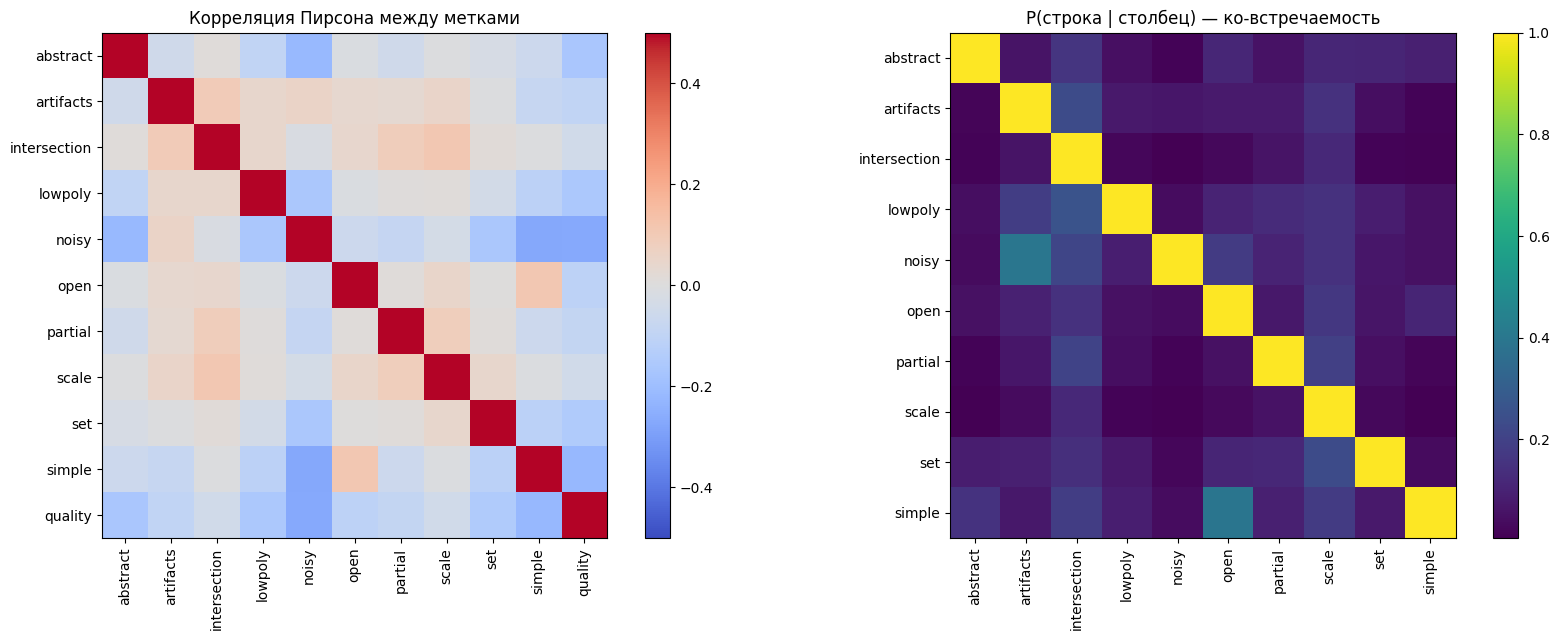

Число дефектов на объект:
0    1372
1    6372
2     878
3     251
4      59
5      25
6       7


In [7]:
                                             
corr = train_df[CFG.target_cols].corr()
fig, ax = plt.subplots(1, 2, figsize=(17, 6.5))
im = ax[0].imshow(corr, cmap='coolwarm', vmin=-.5, vmax=.5)
ax[0].set_xticks(range(11)); ax[0].set_xticklabels(CFG.target_cols, rotation=90)
ax[0].set_yticks(range(11)); ax[0].set_yticklabels(CFG.target_cols)
ax[0].set_title('Корреляция Пирсона между метками'); plt.colorbar(im, ax=ax[0], fraction=0.046)

A = train_df[CFG.artifact_cols].values
cond = np.zeros((10, 10))
for i in range(10):
    for j in range(10):
        cond[i, j] = A[A[:, j] == 1, i].mean() if A[:, j].sum() else 0
im2 = ax[1].imshow(cond, cmap='viridis')
ax[1].set_xticks(range(10)); ax[1].set_xticklabels(CFG.artifact_cols, rotation=90)
ax[1].set_yticks(range(10)); ax[1].set_yticklabels(CFG.artifact_cols)
ax[1].set_title('P(строка | столбец) — ко-встречаемость'); plt.colorbar(im2, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()

print('Число дефектов на объект:')
print(train_df[CFG.artifact_cols].sum(1).value_counts().sort_index().to_string())

In [8]:
from sklearn.metrics import f1_score

def competition_metric(y_true, y_pred):
    """10*F1(quality) + 10*F1_weighted(10 дефектов) — точная формула организаторов."""
    f1_q = f1_score(y_true[:, 10], y_pred[:, 10], zero_division=0)
    f1_a = f1_score(y_true[:, :10], y_pred[:, :10], average='weighted', zero_division=0)
    return 10 * f1_q + 10 * f1_a, f1_q, f1_a

                                                                                          
Y = train_df[CFG.target_cols].values
for err in [0.02, 0.05, 0.10]:
    rng = np.random.default_rng(0)
    fake = Y.copy()
    flip = rng.random(fake[:, :10].shape) < err
    fake[:, :10] = np.abs(fake[:, :10] - flip)
    fake[:, 10] = (fake[:, :10].sum(1) == 0).astype(int)
    s, fq, fa = competition_metric(Y, fake)
    print(f'FPR/FNR по дефектам {err:.0%} -> метрика {s:5.2f} (quality F1={fq:.3f}, artefacts F1={fa:.3f})')
print('\n>>> Ошибка 5% по дефектам уже срезает quality F1 до ~0.7. '
      'Поэтому quality предсказывается ОТДЕЛЬНОЙ головой, а не только правилом.')

FPR/FNR по дефектам 2% -> метрика 17.99 (quality F1=0.878, artefacts F1=0.921)
FPR/FNR по дефектам 5% -> метрика 15.21 (quality F1=0.694, artefacts F1=0.827)
FPR/FNR по дефектам 10% -> метрика 11.69 (quality F1=0.462, artefacts F1=0.706)

>>> Ошибка 5% по дефектам уже срезает quality F1 до ~0.7. Поэтому quality предсказывается ОТДЕЛЬНОЙ головой, а не только правилом.


In [9]:
from PIL import Image
from concurrent.futures import ProcessPoolExecutor

Image.MAX_IMAGE_PIXELS = None

def infer_grid(w, h):
    """(rows, cols) для 6 видов по соотношению сторон."""
    ar = w / h
    cands = {(2, 3): 3 / 2, (3, 2): 2 / 3, (1, 6): 6.0, (6, 1): 1 / 6}
    return min(cands, key=lambda k: abs(math.log(ar / cands[k])))

def split_views(img):
    """PIL.Image -> список из 6 PIL.Image в каноническом порядке чтения."""
    w, h = img.size
    r, c = infer_grid(w, h)
    tw, th = w // c, h // r
    return [img.crop((j * tw, i * th, (j + 1) * tw, (i + 1) * th)) for i in range(r) for j in range(c)]

def make_cache(args):
    src, dst, tile = args
    try:
        img = Image.open(src).convert('RGB')
        views = [v.resize((tile, tile), Image.BILINEAR) for v in split_views(img)]
        out = Image.new('RGB', (3 * tile, 2 * tile))
        for k, v in enumerate(views):
            out.paste(v, ((k % 3) * tile, (k // 3) * tile))
        out.save(dst, format='PNG', optimize=False, compress_level=1)
        return 1
    except Exception:
        return 0

def build_image_cache(ids, src_dir, split):
    out_dir = CFG.cache / f'img_{split}_{CFG.tile}'
    out_dir.mkdir(parents=True, exist_ok=True)
    jobs = [(str(Path(src_dir) / f'{i}.png'), str(out_dir / f'{i}.png'), CFG.tile)
            for i in ids if not (out_dir / f'{i}.png').exists()
            and (Path(src_dir) / f'{i}.png').exists()]
    if jobs:
        with ProcessPoolExecutor(max_workers=os.cpu_count()) as ex:
            ok = list(tqdm(ex.map(make_cache, jobs, chunksize=32), total=len(jobs),
                           desc=f'cache {split}'))
        print(f'{split}: закэшировано {sum(ok)}/{len(jobs)}')
    missing = [i for i in ids if not (out_dir / f'{i}.png').exists()]
    print(f'{split}: всего в кэше {len(ids) - len(missing)}/{len(ids)}, нет картинки у {len(missing)}')
    return out_dir, set(missing)

                                                                                       
_probe = [Image.open(Path(TRAIN_DIR) / f'{i}.png').size
          for i in train_df['item_id'].head(40) if (Path(TRAIN_DIR) / f'{i}.png').exists()]
if _probe:
    _sizes = pd.Series([f'{w}x{h}' for w, h in _probe]).value_counts()
    print('исходные размеры листа с 6 видами:'); print(_sizes.head(5).to_string())
    _w, _h = _probe[0]
    _r, _c = infer_grid(_w, _h)
    _native = min(_w // _c, _h // _r)
    print(f'-> раскладка {_r}x{_c}, нативный размер одного вида ~{_native} px')
    if CFG.tile > _native:
        print(f'!! CFG.tile = {CFG.tile} БОЛЬШЕ нативного {_native}: это апскейл, он удорожает '
              f'обучение, но новой информации не даёт. Снижаю tile до {_native}.')
        CFG.tile = int(_native)
    else:
        print(f'   CFG.tile = {CFG.tile} <= нативного — детали сохраняются')

IMG_TRAIN, MISS_TRAIN = build_image_cache(train_df['item_id'].tolist(), TRAIN_DIR, 'train')
IMG_TEST,  MISS_TEST  = build_image_cache(test_df['item_id'].tolist(),  TEST_DIR,  'test')

исходные размеры листа с 6 видами:
1536x1024    40
-> раскладка 2x3, нативный размер одного вида ~512 px
   CFG.tile = 448 <= нативного — детали сохраняются
train: всего в кэше 8964/8964, нет картинки у 0
test: всего в кэше 669/669, нет картинки у 0


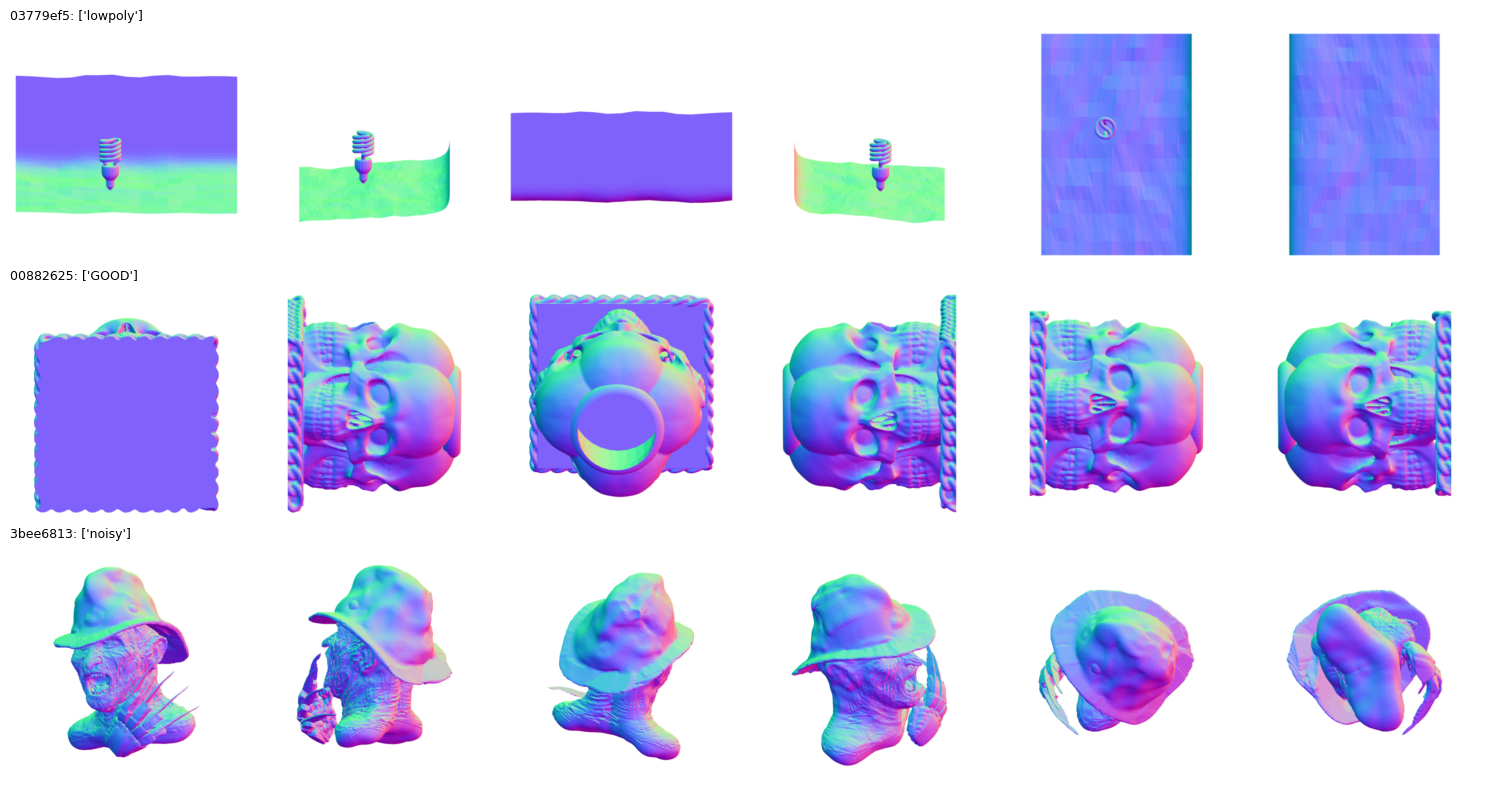

In [10]:
                                                                     
seed_everything()
sample_ids = train_df.sample(3, random_state=0)['item_id'].tolist()
fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for r, iid in enumerate(sample_ids):
    views = split_views(Image.open(IMG_TRAIN / f'{iid}.png').convert('RGB'))
    lbl = [c for c in CFG.artifact_cols if train_df.loc[train_df.item_id == iid, c].iloc[0] == 1]
    for k, v in enumerate(views):
        axes[r, k].imshow(v); axes[r, k].axis('off')
        if k == 0:
            axes[r, k].set_title(f'{iid[:8]}: {lbl or ["GOOD"]}', loc='left', fontsize=9)
plt.tight_layout(); plt.show()

In [11]:
import os, gc, math, numpy as np, pandas as pd
from pathlib import Path
from PIL import Image
from scipy import ndimage
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from scipy.spatial import ConvexHull, QhullError
from concurrent.futures import ProcessPoolExecutor
from concurrent.futures.process import BrokenProcessPool
import multiprocessing as mp

FACE_CAP  = 300_000
VERT_CAP  = 200_000
HULL_CAP  = 20_000
COMP_CAP  = 3_000_000
WELD_TOL  = 1e-6                              
FEAT_VER  = 'v3weld'                                                                 
                                                                               
N_WORKERS = min(4, os.cpu_count() or 2)
CHUNK     = 1024

def _pack21(q):
    """Три целых из [0, 2**21) -> один int64. Точно, без коллизий."""
    return (q[:, 0] << 42) | (q[:, 1] << 21) | q[:, 2]

def _hash3(q):
    q = q.astype(np.int64, copy=False)
    return (q[:, 0] * 73856093) ^ (q[:, 1] * 19349663) ^ (q[:, 2] * 83492791)

def _stats(x, pref):
    keys = ['mean', 'std', 'p10', 'p50', 'p90', 'max', 'cv']
    if len(x) == 0:
        return {f'{pref}_{k}': 0.0 for k in keys}
    x = np.asarray(x, dtype=np.float32)
    m, s = float(x.mean()), float(x.std())
    q10, q50, q90 = np.percentile(x, [10, 50, 90])
    return {f'{pref}_mean': m, f'{pref}_std': s, f'{pref}_p10': float(q10),
            f'{pref}_p50': float(q50), f'{pref}_p90': float(q90),
            f'{pref}_max': float(x.max()), f'{pref}_cv': float(s / (abs(m) + 1e-9))}

def _edge_table(Fi, nfw):
    """Рёбра -> (номер группы, число граней на ребро, отсортированные id граней)."""
    E = np.concatenate([Fi[:, [0, 1]], Fi[:, [1, 2]], Fi[:, [2, 0]]], 0)
    E.sort(axis=1)
    fid = np.tile(np.arange(nfw, dtype=np.int32), 3)
    order = np.lexsort((E[:, 1], E[:, 0]))
    Es, fids = E[order], fid[order]
    new = np.ones(len(Es), dtype=bool)
    new[1:] = (Es[1:] != Es[:-1]).any(1)
    grp = np.cumsum(new) - 1
    counts = np.bincount(grp)
    return E, Es, fids, grp, counts, new

def mesh_features(npz_path):
    f = {'geo_ok': 0.0, 'geo_subsampled': 0.0}
    try:
        f['npz_mb'] = os.path.getsize(npz_path) / 1e6
    except Exception:
        return f
    try:
        with np.load(npz_path, allow_pickle=False) as d:
            keys = list(d.keys())
            V = np.asarray(d['vertices' if 'vertices' in keys else keys[0]], dtype=np.float32)
            Fc = None
            for k in ('faces', 'triangles', 'f'):
                if k in keys:
                    Fc = np.asarray(d[k], dtype=np.int64); break
            if Fc is None and len(keys) > 1:
                Fc = np.asarray(d[keys[1]], dtype=np.int64)
    except Exception:
        return f
    if V.ndim != 2 or V.shape[1] != 3 or len(V) == 0:
        return f
    if Fc is None or Fc.ndim != 2 or Fc.shape[1] != 3 or len(Fc) == 0:
        Fc = np.zeros((0, 3), dtype=np.int64)
    else:
        Fc = Fc[(Fc >= 0).all(1) & (Fc < len(V)).all(1)]

    f['geo_ok'] = 1.0
    nv_raw, nf_raw = len(V), len(Fc)
    vmin, vmax = V.min(0), V.max(0)
    ext = (vmax - vmin).astype(np.float64)
    ext_s = np.sort(ext)[::-1]
    diag = float(np.linalg.norm(ext)) + 1e-12
    center = ((vmin + vmax) / 2).astype(np.float32)
    inv_s = np.float32(1.0 / diag)
    f.update({'n_verts_raw': float(nv_raw), 'n_faces': float(nf_raw),
              'log_verts': math.log1p(nv_raw), 'log_faces': math.log1p(nf_raw),
              'ext_max': float(ext_s[0]), 'ext_mid': float(ext_s[1]), 'ext_min': float(ext_s[2]),
              'ext_ratio_min': float(ext_s[2] / (ext_s[0] + 1e-12)),
              'ext_ratio_mid': float(ext_s[1] / (ext_s[0] + 1e-12)),
              'bbox_diag': diag,
              'bbox_fill': float(nv_raw / (ext.prod() + 1e-12)) if ext.prod() > 0 else 0.0})

                                                         
                                                                                           
                                                                                         
                                                                                                
    step = np.float32(diag * WELD_TOL)
    q = np.clip(np.rint((V - vmin) / step), 0, (1 << 21) - 1).astype(np.int64)
    code = _pack21(q)
    del q
    ucode, first, invmap = np.unique(code, return_index=True, return_inverse=True)
    del code, ucode
    nv = len(first)
    f['n_verts'] = float(nv)
    f['weld_ratio'] = float(1.0 - nv / max(nv_raw, 1))                                                         
    f['f_per_v'] = nf_raw / max(nv, 1)
    Vw_full = V[first]
    del first

    if nf_raw:
        Fw = invmap[Fc]
        ok = (Fw[:, 0] != Fw[:, 1]) & (Fw[:, 1] != Fw[:, 2]) & (Fw[:, 0] != Fw[:, 2])
        f['degen_after_weld'] = float(1.0 - ok.mean())
        Fw = Fw[ok]
        hf = _hash3(np.sort(Fw, axis=1))
        _, uidx = np.unique(hf, return_index=True)
        f['dup_face_ratio'] = float(1.0 - len(uidx) / max(len(Fw), 1))
        Fw = Fw[np.sort(uidx)]
        del hf, uidx, ok
    else:
        Fw = np.zeros((0, 3), dtype=np.int64)
        f['degen_after_weld'] = 0.0; f['dup_face_ratio'] = 0.0
    del invmap, Fc
    nf = len(Fw)

                                                 
    Vs = Vw_full[::max(1, int(np.ceil(nv / VERT_CAP)))]
    if nv > VERT_CAP:
        f['geo_subsampled'] = 1.0
    Vs = (Vs - center) * inv_s
    try:
        if len(Vs) < 3:
            raise ValueError('too few vertices')
        ev = np.clip(np.linalg.eigvalsh(np.cov(Vs.T.astype(np.float64)))[::-1], 1e-16, None)
        f.update({'pca_1': float(ev[0]), 'pca_2': float(ev[1]), 'pca_3': float(ev[2]),
                  'pca_flat': float(ev[2] / ev[0]), 'pca_lin': float(ev[1] / ev[0]),
                  'pca_aniso': float((ev[0] - ev[2]) / ev.sum())})
    except Exception:
        f.update({k: 0.0 for k in ['pca_1', 'pca_2', 'pca_3', 'pca_flat', 'pca_lin', 'pca_aniso']})

                                                                       
    f.update({'hull_ok': 0.0, 'solidity': 0.0, 'solidity_signed': 0.0, 'hull_area_ratio': 0.0,
              'hull_pts_frac': 0.0, 'sphericity': 0.0, 'hull_vol': 0.0, 'hull_area': 0.0})
    try:
        Vh = Vs[::max(1, int(np.ceil(len(Vs) / HULL_CAP)))].astype(np.float64)
        if len(Vh) >= 8:
            hull = ConvexHull(Vh, qhull_options='QJ')
            f['hull_ok'] = 1.0
            f['hull_vol'] = float(hull.volume)
            f['hull_pts_frac'] = len(hull.vertices) / len(Vh)
            f['hull_area'] = float(hull.area)
    except (QhullError, ValueError, MemoryError):
        pass

    if nf == 0:
        f['no_faces'] = 1.0
        f.update({'area_total': 0.0, 'volume': 0.0, 'abs_volume': 0.0, 'vol_ratio': 0.0,
                  'vol_over_area': 0.0, 'absvol_over_area': 0.0, 'vol_over_bbox': 0.0,
                  'absvol_over_bbox': 0.0})
        for pref in ('dihed', 'dihedf', 'farea', 'elen', 'aspect', 'valence', 'defect'):
            f.update(_stats([], pref))
        return f
    f['no_faces'] = 0.0

                                                               
    total_area, vol6, absvol6 = 0.0, 0.0, 0.0
    for s0 in range(0, nf, 500_000):
        Pc = ((Vw_full[Fw[s0:s0 + 500_000]] - center) * inv_s).astype(np.float64)
        cr_c = np.cross(Pc[:, 1] - Pc[:, 0], Pc[:, 2] - Pc[:, 0])
        total_area += 0.5 * float(np.linalg.norm(cr_c, axis=1).sum())
        contrib = (Pc[:, 0] * np.cross(Pc[:, 1], Pc[:, 2])).sum(1)
        vol6 += float(contrib.sum()); absvol6 += float(np.abs(contrib).sum())
        del Pc, cr_c, contrib
    total_area += 1e-12
    vol = abs(vol6 / 6.0)
    absvol = absvol6 / 6.0
                                                                                            
                                                                                            
    f.update({'area_total': total_area, 'volume': vol, 'abs_volume': absvol,
              'vol_ratio': vol / (absvol + 1e-12),
              'vol_over_area': vol / (total_area ** 1.5 + 1e-12),
              'absvol_over_area': absvol / (total_area ** 1.5 + 1e-12),
              'vol_over_bbox': vol / (float(np.prod(ext * inv_s)) + 1e-12),
              'absvol_over_bbox': absvol / (float(np.prod(ext * inv_s)) + 1e-12)})
    if f['hull_ok']:
        f['solidity'] = absvol / (f['hull_vol'] + 1e-12)
        f['solidity_signed'] = vol / (f['hull_vol'] + 1e-12)
        f['hull_area_ratio'] = total_area / (f.get('hull_area', 0.0) + 1e-12)
        f['sphericity'] = (math.pi ** (1 / 3)) * (6 * absvol) ** (2 / 3) / (total_area + 1e-12)

                                                             
    f.update({'n_comp': 1.0, 'n_comp_big': 1.0, 'comp_top1': 1.0, 'comp_top2': 0.0,
              'comp_entropy': 0.0, 'bbox_iou_max': 0.0, 'bbox_iou_mean': 0.0,
              'bbox_iou_frac_pos': 0.0, 'comp_sep_max': 0.0, 'comp_sep_mean': 0.0,
              'inside_frac_max': 0.0, 'comp_exact': 1.0})
    if nf <= COMP_CAP:
        try:
            Ef = np.concatenate([Fw[:, [0, 1]], Fw[:, [1, 2]], Fw[:, [2, 0]]], 0).astype(np.int32)
            A = coo_matrix((np.ones(len(Ef), dtype=np.int8), (Ef[:, 0], Ef[:, 1])), shape=(nv, nv))
            del Ef
            ncomp, lab = connected_components(A, directed=False)
            del A
            used = np.unique(Fw)
            sizes_all = np.bincount(lab[used], minlength=ncomp).astype(np.float64)
            sizes = np.sort(sizes_all[sizes_all > 0])[::-1]
            tot = sizes.sum()
            big_idx = np.where(sizes_all > 0.005 * tot)[0]
            f.update({'n_comp': float(len(sizes)), 'n_comp_big': float(len(big_idx)),
                      'comp_top1': float(sizes[0] / tot),
                      'comp_top2': float(sizes[1] / tot) if len(sizes) > 1 else 0.0,
                      'comp_entropy': float(-((sizes / tot) * np.log(sizes / tot + 1e-12)).sum())})
            if len(big_idx) > 1:
                top = big_idx[np.argsort(-sizes_all[big_idx])][:8]
                pts_l, boxes = [], []
                for c in top:
                    ic = used[lab[used] == c]
                    if len(ic) > 20_000:
                        ic = ic[::len(ic) // 20_000 + 1]
                    p = (Vw_full[ic] - center) * inv_s
                    pts_l.append(p); boxes.append((p.min(0), p.max(0)))
                ious, seps, insides = [], [], []
                for i in range(len(boxes)):
                    for j in range(len(boxes)):
                        if i == j:
                            continue
                        lo, hi = boxes[j]
                        insides.append(float(((pts_l[i] >= lo) & (pts_l[i] <= hi)).all(1).mean()))
                        if j <= i:
                            continue
                        lo2 = np.maximum(boxes[i][0], boxes[j][0])
                        hi2 = np.minimum(boxes[i][1], boxes[j][1])
                        it = float(np.prod(np.clip(hi2 - lo2, 0, None)))
                        vi = float(np.prod(np.clip(boxes[i][1] - boxes[i][0], 1e-6, None)))
                        vj = float(np.prod(np.clip(boxes[j][1] - boxes[j][0], 1e-6, None)))
                        ious.append(it / (vi + vj - it + 1e-12))
                        seps.append(float(np.linalg.norm(
                            (boxes[i][0] + boxes[i][1]) / 2 - (boxes[j][0] + boxes[j][1]) / 2)))
                f.update({'bbox_iou_max': float(max(ious)), 'bbox_iou_mean': float(np.mean(ious)),
                          'bbox_iou_frac_pos': float(np.mean(np.asarray(ious) > 1e-6)),
                          'comp_sep_max': float(max(seps)), 'comp_sep_mean': float(np.mean(seps)),
                          'inside_frac_max': float(max(insides))})
            del lab, sizes_all, sizes, used
        except Exception:
            f['comp_exact'] = 0.0
    else:
        f['comp_exact'] = 0.0

                                                            
    if nf > FACE_CAP:
        f['geo_subsampled'] = 1.0
        anchor = (Vw_full[Fw[:, 0]] - vmin) / (ext.astype(np.float32) + 1e-9)
        Fp, g = None, 1
        while g < 40:
            g += 1
            cid = np.minimum((anchor * g).astype(np.int32), g - 1)
            key = (cid[:, 0] * g + cid[:, 1]) * g + cid[:, 2]
            cnt = np.bincount(key, minlength=g ** 3)
            best = int(np.argmax(cnt))
            if cnt[best] <= FACE_CAP:
                Fp = Fw[key == best]; break
        if Fp is None or len(Fp) < 1000:
            Fp = Fw[:FACE_CAP]
        f['patch_grid'] = float(g)
        del anchor
    else:
        Fp = Fw
        f['patch_grid'] = 1.0
    f['patch_face_frac'] = len(Fp) / max(nf, 1)
    del Fw
    nfw = len(Fp)

    uvp, Fi = np.unique(Fp, return_inverse=True)
    Fi = Fi.reshape(nfw, 3).astype(np.int32)
    Vp = ((Vw_full[uvp] - center) * inv_s).astype(np.float32)
    nvp = len(uvp)
    del uvp, Fp, Vw_full, V

    P = Vp[Fi]
    cr = np.cross(P[:, 1] - P[:, 0], P[:, 2] - P[:, 0])
    area2 = np.linalg.norm(cr, axis=1)
    area = 0.5 * area2
    nrm = cr / (area2[:, None] + 1e-12)
    del cr
    f.update(_stats(area / (area.mean() + 1e-12), 'farea'))
    f['degenerate_ratio'] = float((area < 1e-10).mean())

    L = np.stack([np.linalg.norm(P[:, 1] - P[:, 0], axis=1),
                  np.linalg.norm(P[:, 2] - P[:, 1], axis=1),
                  np.linalg.norm(P[:, 0] - P[:, 2], axis=1)], 1)
    f.update(_stats(L.ravel() / (L.mean() + 1e-12), 'elen'))
    aspect = L.max(1) / (L.min(1) + 1e-12)
    f.update(_stats(np.log1p(aspect), 'aspect'))
    f['sliver_ratio'] = float((aspect > 20).mean())

    for qd in (1, 2):
        f[f'uniq_normals_q{qd}'] = len(np.unique(_hash3(np.rint(nrm * 10 ** qd)))) / nfw
                                                                               
    hn = _hash3(np.rint(nrm * 20))
    _, ninv = np.unique(hn, return_inverse=True)
    mass = np.bincount(ninv, weights=area)
    mass = np.sort(mass)[::-1]
    f['normal_top6_mass'] = float(mass[:6].sum() / (mass.sum() + 1e-12))
    f['normal_top1_mass'] = float(mass[0] / (mass.sum() + 1e-12))
    del hn, ninv, mass

                                                                              
    E, Es, fids, grp, counts, _ = _edge_table(Fi, nfw)
    n_edges = len(counts)
    f.update({'n_edges': float(n_edges),
              'boundary_edge_ratio': float((counts == 1).mean()),
              'nonmanifold_edge_ratio': float((counts >= 3).mean()),
              'euler_norm': float((nvp - n_edges + nfw) / max(nfw, 1)),
              'euler_char': float(nvp - n_edges + nfw),
              'watertight': float((counts == 1).sum() == 0 and (counts >= 3).sum() == 0),
              'manifold_edge_ratio': float((counts == 2).mean())})

                                                                  
    bnd = np.where(counts == 1)[0]
    if len(bnd):
        st = np.searchsorted(grp, bnd)
        be = Es[st]
        try:
            Ab = coo_matrix((np.ones(len(be), dtype=np.int8), (be[:, 0], be[:, 1])), shape=(nvp, nvp))
            nb_comp, lb = connected_components(Ab, directed=False)
            used_b = np.unique(be)
            f['n_boundary_loops'] = float(len(np.unique(lb[used_b])))
            f['boundary_vert_frac'] = float(len(used_b) / nvp)
            del Ab, lb, used_b
        except Exception:
            f['n_boundary_loops'] = 0.0; f['boundary_vert_frac'] = 0.0
        del be, st
    else:
        f['n_boundary_loops'] = 0.0; f['boundary_vert_frac'] = 0.0

    two = np.where(counts == 2)[0]
    if len(two):
        st = np.searchsorted(grp, two)
        fa, fb = fids[st], fids[st + 1]
        cosang = np.clip((nrm[fa] * nrm[fb]).sum(1), -1, 1)
        ang = np.degrees(np.arccos(cosang))
        angf = np.degrees(np.arccos(np.abs(cosang)))
        f.update(_stats(ang, 'dihed')); f.update(_stats(angf, 'dihedf'))
        for t in (10, 30, 60, 90):
            f[f'dihed_gt{t}'] = float((ang > t).mean())
        for t in (5, 15, 30, 60):
            f[f'dihedf_gt{t}'] = float((angf > t).mean())
        f['flip_ratio'] = float((cosang < 0).mean())
        hist = np.bincount((angf / 5).astype(np.int32).clip(0, 17), minlength=18).astype(np.float64)
        p = hist / max(hist.sum(), 1)
        f['dihed_entropy'] = float(-(p[p > 0] * np.log(p[p > 0])).sum())
        f['smoothness'] = float(angf.mean() * math.sqrt(nfw) / 100.0)
                                                                           
        el = np.linalg.norm(Vp[Es[st][:, 0]] - Vp[Es[st][:, 1]], axis=1)
        f['dihedf_areaw'] = float((angf * el).sum() / (el.sum() + 1e-12))
        del fa, fb, cosang, ang, angf, el
    else:
        f.update(_stats([], 'dihed')); f.update(_stats([], 'dihedf'))
        for t in (10, 30, 60, 90):
            f[f'dihed_gt{t}'] = 0.0
        for t in (5, 15, 30, 60):
            f[f'dihedf_gt{t}'] = 0.0
        f.update({'flip_ratio': 0.0, 'dihed_entropy': 0.0, 'smoothness': 0.0, 'dihedf_areaw': 0.0})

                                                                       
    val = np.bincount(Fi.ravel(), minlength=nvp).astype(np.float32)
    f.update(_stats(val, 'valence'))
    f['valence_le3'] = float((val <= 3).mean())
    f['valence_ge8'] = float((val >= 8).mean())
    e01 = P[:, 1] - P[:, 0]; e12 = P[:, 2] - P[:, 1]; e20 = P[:, 0] - P[:, 2]
    def _ang(u, v):
        cu = (u * v).sum(1) / (np.linalg.norm(u, axis=1) * np.linalg.norm(v, axis=1) + 1e-12)
        return np.arccos(np.clip(cu, -1, 1))
    a0 = _ang(e01, -e20); a1 = _ang(e12, -e01); a2 = _ang(e20, -e12)
    defect = np.full(nvp, 2 * np.pi, dtype=np.float64)
    np.subtract.at(defect, Fi[:, 0], a0)
    np.subtract.at(defect, Fi[:, 1], a1)
    np.subtract.at(defect, Fi[:, 2], a2)
    interior = val > 0
    f.update(_stats(np.abs(defect[interior]), 'defect'))
    f['defect_sum'] = float(defect[interior].sum() / (2 * np.pi))                                
    f['defect_gt05'] = float((np.abs(defect[interior]) > 0.5).mean())
    del defect, val, a0, a1, a2, e01, e12, e20

    del E, Es, fids, grp, counts, two, nrm, P, Vp, Fi, L, aspect, area, area2
    return f

In [12]:
def image_features(png_path):
    f = {'img_ok': 0.0}
    try:
        img = Image.open(png_path).convert('L')
    except Exception:
        return f
    a = np.asarray(img, dtype=np.float32) / 255.0
    t = CFG.tile
    f['img_ok'] = 1.0
    covs, comps, edens, stds, bws, bhs = [], [], [], [], [], []
    for k in range(6):
        v = a[(k // 3) * t:(k // 3 + 1) * t, (k % 3) * t:(k % 3 + 1) * t]
        bg = np.median(np.concatenate([v[0], v[-1], v[:, 0], v[:, -1]]))
        mask = np.abs(v - bg) > 0.06
        cov = float(mask.mean()); covs.append(cov)
        if mask.any():
            ys, xs = np.where(mask)
            bws.append((xs.max() - xs.min() + 1) / t)
            bhs.append((ys.max() - ys.min() + 1) / t)
            lab, ncc = ndimage.label(mask)
            if ncc:
                sz = np.bincount(lab.ravel())[1:]
                comps.append(float((sz > 0.01 * sz.sum()).sum()))
            else:
                comps.append(0.0)
        else:
            bws.append(0.0); bhs.append(0.0); comps.append(0.0)
        edens.append(float(np.abs(np.diff(v, axis=1)).mean() + np.abs(np.diff(v, axis=0)).mean()))
        stds.append(float(v.std()))
    def agg(vals, pref):
        v = np.asarray(vals, dtype=np.float64)
        return {f'{pref}_mean': v.mean(), f'{pref}_min': v.min(), f'{pref}_max': v.max(),
                f'{pref}_std': v.std(), f'{pref}_range': v.max() - v.min()}
    f.update(agg(covs, 'cov')); f.update(agg(comps, 'ncc')); f.update(agg(edens, 'edge'))
    f.update(agg(stds, 'pxstd')); f.update(agg(bws, 'bw')); f.update(agg(bhs, 'bh'))
    f['cov_empty_views'] = float((np.asarray(covs) < 0.01).sum())
    f['bbox_fill_view'] = float(np.mean(np.asarray(covs) /
                                        (np.asarray(bws) * np.asarray(bhs) + 1e-6)))
    return f

def _feat_one(args):
    iid, npz, png = args
    d = {'item_id': iid}
    try:
        d.update(mesh_features(npz))
    except (MemoryError, Exception):
        d['geo_ok'] = 0.0
    try:
        d.update(image_features(png))
    except Exception:
        d['img_ok'] = 0.0
    return d

def build_features(ids, npz_dir, img_dir, split):
    """Чанками, с чекпоинтом и резюмированием. Повторный запуск после падения
    продолжает с последнего сохранённого чанка."""
    final = CFG.cache / f'feats_{split}_{CFG.tile}_{FEAT_VER}.parquet'
    ckpt  = CFG.cache / f'feats_{split}_{CFG.tile}_{FEAT_VER}_partial.parquet'
    if final.exists():
        df = pd.read_parquet(final); print(f'{split}: фичи из кэша {df.shape}'); return df

    done = pd.read_parquet(ckpt) if ckpt.exists() else pd.DataFrame(columns=['item_id'])
    have = set(done['item_id'].astype(str)) if len(done) else set()
    todo = [i for i in ids if i not in have]
    print(f'{split}: уже готово {len(have)}, осталось {len(todo)}, воркеров {N_WORKERS}')

    rows = [done] if len(done) else []
    for s in range(0, len(todo), CHUNK):
        part = todo[s:s + CHUNK]
        jobs = [(i, str(Path(npz_dir) / f'{i}.npz'), str(Path(img_dir) / f'{i}.png')) for i in part]
                                                                                           
                                                                                               
                                                                                  
                                                                   
        try:
            ctx = mp.get_context('fork')
        except ValueError:
            ctx = None
        try:
            with ProcessPoolExecutor(max_workers=N_WORKERS, mp_context=ctx) as ex:
                got = list(tqdm(ex.map(_feat_one, jobs, chunksize=4), total=len(jobs),
                                desc=f'{split} {s + len(part)}/{len(todo)}', leave=False))
        except (BrokenProcessPool, OSError, MemoryError) as e:
            print(f'  пул упал ({type(e).__name__}), чанк считается последовательно')
            got = [_feat_one(j) for j in tqdm(jobs, desc='serial', leave=False)]
        rows.append(pd.DataFrame(got))
        _atomic(ckpt, lambda p: pd.concat(rows, ignore_index=True).to_parquet(p, index=False))
        gc.collect()

    df = pd.concat(rows, ignore_index=True).drop_duplicates('item_id')
    df = df.set_index('item_id').reindex([str(i) for i in ids]).reset_index()
    df = df.fillna(0.0)
    _atomic(final, lambda p: df.to_parquet(p, index=False))
    if ckpt.exists():
        ckpt.unlink()
    print(f'{split}: фичи посчитаны {df.shape}')
    return df

feat_tr = build_features(train_df['item_id'].tolist(), TRAIN_DIR, IMG_TRAIN, 'train')
feat_te = build_features(test_df['item_id'].tolist(),  TEST_DIR,  IMG_TEST,  'test')

train: фичи из кэша (8964, 170)
test: фичи из кэша (669, 170)


In [13]:
CLIP_PROMPTS = {
                                            
    'abs_text':     ['3D text lettering', 'a sign with written words', 'an extruded logo'],
    'abs_chart':    ['a bar chart', 'a pie chart', 'a graph plot', 'a diagram', 'a flowchart',
                     'a table with data', 'an infographic'],
    'abs_support':  ['3D printing support structure', 'scaffolding lattice'],
    'abs_voxel':    ['minecraft voxel blocks', 'blocky pixelated cubes'],
                                                     
    'obj_single':   ['a 3D model of a single object', 'a product render on white background'],
    'obj_semantic': ['a chair', 'a car', 'a building', 'a plant', 'a character figure',
                     'a tool', 'furniture'],
                                          
    'p_lowpoly':    ['a low-poly 3D model with visible flat facets'],
    'p_noisy':      ['a noisy 3D scan with rough surface', 'a point cloud scan'],
    'p_broken':     ['a broken mesh with holes and artifacts'],
    'p_hollow':     ['a hollow thin shell', 'a flat plane'],
    'p_multi':      ['several separate objects scattered apart', 'a collection of many objects'],
    'p_small':      ['a tiny object in the middle of a large empty frame'],
    'p_smooth':     ['a smooth clean 3D render of one object'],
}

def compute_clip_features(ids, img_dir, split):
    import open_clip
    name, pretrained = CFG.clip_model
    model, _, _ = open_clip.create_model_and_transforms(name, pretrained=pretrained)
    tokenizer = open_clip.get_tokenizer(name)
    model = model.to(CFG.device).eval()

    groups = list(CLIP_PROMPTS)
    flat, owner = [], []
    for g in groups:
        flat += CLIP_PROMPTS[g]; owner += [g] * len(CLIP_PROMPTS[g])
    with torch.no_grad():
        tf = model.encode_text(tokenizer(flat).to(CFG.device)).float()
        tf = tf / tf.norm(dim=-1, keepdim=True)
    owner = np.array(owner)

    size = model.visual.image_size
    size = size[0] if isinstance(size, (tuple, list)) else int(size)
    mean = torch.tensor([0.48145466, 0.4578275, 0.40821073], device=CFG.device).view(1, 3, 1, 1)
    std = torch.tensor([0.26862954, 0.26130258, 0.27577711], device=CFG.device).view(1, 3, 1, 1)

    rows, bs = [], 24
    for s0 in tqdm(range(0, len(ids), bs), desc=f'CLIP {split}'):
        chunk = ids[s0:s0 + bs]
        batch = []
        for iid in chunk:
            p = Path(img_dir) / f'{iid}.png'
            if p.exists():
                vs = [np.asarray(v.resize((size, size), Image.BILINEAR), dtype=np.uint8)
                      for v in split_views(Image.open(p).convert('RGB'))]
            else:
                vs = [np.full((size, size, 3), 255, np.uint8)] * 6
            batch.append(np.stack(vs))
        x = torch.from_numpy(np.stack(batch)).to(CFG.device)                              
        B = x.shape[0]
        x = x.permute(0, 1, 4, 2, 3).reshape(B * 6, 3, size, size).float() / 255.0
        x = (x - mean) / std
        with torch.no_grad():
            im = model.encode_image(x).float()
        im = im / im.norm(dim=-1, keepdim=True)
        sim = (im @ tf.T).view(B, 6, -1).cpu().numpy()

        gsim = np.stack([sim[:, :, owner == g].max(-1) for g in groups], -1)                   
        feat = {}
        for j, g in enumerate(groups):
            v = gsim[:, :, j]
            feat[f'clip_{g}_mean'] = v.mean(1)
            feat[f'clip_{g}_max'] = v.max(1)
            feat[f'clip_{g}_std'] = v.std(1)
        abs_max = np.stack([feat[f'clip_{g}_max'] for g in groups if g.startswith('abs_')], 1).max(1)
        obj_max = np.stack([feat[f'clip_{g}_max'] for g in groups if g.startswith('obj_')], 1).max(1)
        def_max = np.stack([feat[f'clip_{g}_max'] for g in groups
                            if g.startswith('p_') and g != 'p_smooth'], 1).max(1)
        feat['clip_abstract_margin'] = abs_max - obj_max
        feat['clip_abstract_prob'] = 1 / (1 + np.exp(-100 * (abs_max - obj_max)))
        feat['clip_defect_margin'] = def_max - feat['clip_p_smooth_max']
        rows.append(pd.DataFrame(feat, index=list(chunk)))
    del model
    gc.collect(); torch.cuda.empty_cache()
    return pd.concat(rows).rename_axis('item_id').reset_index()

if CFG.use_clip:
    clip_tr = cached(f'clip_train_{CFG.clip_model[0]}',
                     lambda: compute_clip_features(train_df['item_id'].tolist(), IMG_TRAIN, 'train'))
    clip_te = cached(f'clip_test_{CFG.clip_model[0]}',
                     lambda: compute_clip_features(test_df['item_id'].tolist(), IMG_TEST, 'test'))
    feat_tr = feat_tr.merge(clip_tr, on='item_id', how='left')
    feat_te = feat_te.merge(clip_te, on='item_id', how='left')
    print('добавлено CLIP-признаков:', clip_tr.shape[1] - 1)

    _m = train_df.merge(clip_tr, on='item_id', how='left').fillna(0)
    cc = pd.Series({c: np.corrcoef(_m[c], _m['abstract'])[0, 1]
                    for c in clip_tr.columns if c != 'item_id'}).sort_values(key=abs, ascending=False)
    print('\nкорреляция CLIP-признаков с abstract (топ-8):')
    print(cc.head(8).round(3).to_string())
    print('\nдля сравнения: лучший геометро-визуальный признак давал по abstract r = +0.51')
else:
    print('CLIP выключен (CFG.use_clip = False)')

  [кэш] clip_train_ViT-B-32: загружено
  [кэш] clip_test_ViT-B-32: загружено
добавлено CLIP-признаков: 42

корреляция CLIP-признаков с abstract (топ-8):
clip_p_smooth_mean     -0.295
clip_abs_chart_max      0.292
clip_p_noisy_max       -0.269
clip_p_smooth_std       0.267
clip_abstract_margin    0.266
clip_p_noisy_mean      -0.266
clip_p_lowpoly_mean    -0.263
clip_abstract_prob      0.261

для сравнения: лучший геометро-визуальный признак давал по abstract r = +0.51


In [14]:
_ALL_COLS = [c for c in feat_tr.columns if c != 'item_id' and c in feat_te.columns]
                                                                                        
                                                                                             
                                                                                         
FEAT_CLIP = 1e9                                                      

def sanitize_feature_frame(df, cols):
    x = df[cols].to_numpy(dtype=np.float64, copy=True)
    x[~np.isfinite(x)] = 0.0
    np.clip(x, -FEAT_CLIP, FEAT_CLIP, out=x)
    df[cols] = x.astype(np.float32)
    return df

_raw = feat_tr[_ALL_COLS].to_numpy(dtype=np.float64)
print(f'признаки train: нечисловых значений {int((~np.isfinite(_raw)).sum())}, '
      f'по модулю больше {FEAT_CLIP:.0e}: {int((np.abs(np.where(np.isfinite(_raw), _raw, 0)) > FEAT_CLIP).sum())} '
      f'— обнуляются и обрезаются')
sanitize_feature_frame(feat_tr, _ALL_COLS)
sanitize_feature_frame(feat_te, _ALL_COLS)

def dedup_feature_columns():
    """Убираем константные и буквально совпадающие колонки: они только замедляют GBM
    и размывают важность фич между копиями. Сравнение по хешу содержимого колонки."""
    import hashlib
    keep, seen, const, dup = [], {}, [], []
    for c in _ALL_COLS:
        v = np.nan_to_num(feat_tr[c].values.astype(np.float64))
        if v.std() == 0:
            const.append(c); continue
        key = hashlib.md5(np.ascontiguousarray(np.round(v, 9)).tobytes()).hexdigest()
        if key in seen:
            dup.append((c, seen[key])); continue
        seen[key] = c; keep.append(c)
    return {'cols': keep, 'const': const, 'dup': dup}

_fc = cached(f'feat_cols_{CFG.tile}_{FEAT_VER}', dedup_feature_columns)
FEAT_COLS = [c for c in _fc['cols'] if c in feat_te.columns]
print(f'фич всего {len(_ALL_COLS)} -> после дедупликации {len(FEAT_COLS)}')
if _fc['const']:
    print('  константные (выброшены):', ', '.join(_fc['const'][:12]),
          '…' if len(_fc['const']) > 12 else '')
if _fc['dup']:
    print('  дубликаты (выброшены, в скобках — оставленный оригинал):',
          ', '.join(f'{a}({b})' for a, b in _fc['dup'][:12]), '…' if len(_fc['dup']) > 12 else '')
print('подвыборка применялась к', f"{feat_tr['geo_subsampled'].mean():.1%}", 'мешей train')

                                                                                           
                                                                                        
FEAT_SIG = f'{FEAT_VER}_t{CFG.tile}_f{len(FEAT_COLS)}'
L2_SIG = f'{FEAT_SIG}_s{max(1, getattr(CFG, "level2_seeds", 1))}'                          
print('подпись набора признаков:', FEAT_SIG, '| level-2:', L2_SIG)

признаки train: нечисловых значений 0, по модулю больше 1e+09: 12 — обнуляются и обрезаются
  [кэш] feat_cols_448_v3weld: загружено
фич всего 211 -> после дедупликации 207
  константные (выброшены): geo_ok, hull_ok, no_faces, img_ok 
подвыборка применялась к 22.6% мешей train
подпись набора признаков: v3weld_t448_f207 | level-2: v3weld_t448_f207_s3


In [15]:
wr = feat_tr['weld_ratio']
print('доля мешей с дублированными вершинами (weld_ratio > 0.1): %.1f%%' % (100 * (wr > 0.1).mean()))
print('медианный weld_ratio: %.3f  (0.67 = ровно 3 вершины на грань)' % wr.median())
print('watertight после сварки: %.1f%% мешей (до сварки было бы 0%%)' % (100 * feat_tr['watertight'].mean()))
print('манифолдных рёбер (2 грани): в среднем %.1f%% (до сварки было бы 0%%)'
      % (100 * feat_tr['manifold_edge_ratio'].mean()))
print('двугранные углы посчитаны у %.1f%% мешей (до сварки — 0%%)'
      % (100 * (feat_tr['dihedf_mean'] > 0).mean()))

topo = ['boundary_edge_ratio', 'n_boundary_loops', 'watertight', 'nonmanifold_edge_ratio',
        'dihedf_mean', 'dihed_entropy', 'solidity', 'sphericity', 'normal_top6_mass',
        'n_comp', 'comp_top1', 'defect_std', 'valence_std', 'vol_ratio', 'inside_frac_max']
mg = train_df.merge(feat_tr, on='item_id', how='left').fillna(0.0)
tt = pd.DataFrame({t: [np.corrcoef(mg[c], mg[t])[0, 1] for c in topo]
                   for t in CFG.target_cols}, index=topo)
display(tt.round(3).style.background_gradient(cmap='coolwarm', vmin=-.5, vmax=.5))
print('>>> Если в этой таблице есть |r| > 0.2 — топологическая ветка заработала.')

доля мешей с дублированными вершинами (weld_ratio > 0.1): 38.6%
медианный weld_ratio: 0.010  (0.67 = ровно 3 вершины на грань)
watertight после сварки: 30.6% мешей (до сварки было бы 0%)
манифолдных рёбер (2 грани): в среднем 96.6% (до сварки было бы 0%)
двугранные углы посчитаны у 100.0% мешей (до сварки — 0%)


,abstract,artifacts,intersection,lowpoly,noisy,open,partial,scale,set,simple,quality
boundary_edge_ratio,0.144000,0.060000,0.028000,0.013000,-0.080000,0.105000,0.024000,0.045000,0.077000,-0.043000,-0.098000
n_boundary_loops,0.007000,0.018000,0.000000,-0.000000,0.004000,0.022000,0.026000,0.018000,0.044000,-0.029000,-0.029000
watertight,0.065000,-0.089000,-0.013000,-0.030000,-0.253000,-0.010000,-0.101000,-0.057000,-0.066000,0.309000,0.081000
nonmanifold_edge_ratio,0.032000,0.018000,0.022000,0.039000,-0.043000,0.034000,0.036000,0.035000,0.044000,-0.014000,-0.010000
dihedf_mean,0.144000,-0.039000,0.002000,0.089000,-0.262000,0.020000,0.006000,0.025000,0.022000,0.232000,-0.106000
dihed_entropy,-0.185000,0.105000,-0.020000,0.163000,0.255000,-0.112000,0.055000,0.044000,0.027000,-0.251000,-0.081000
solidity,0.013000,-0.007000,-0.003000,-0.011000,-0.019000,0.001000,-0.006000,-0.003000,-0.010000,0.034000,-0.013000
sphericity,0.182000,0.020000,-0.036000,-0.017000,0.019000,-0.014000,-0.028000,0.035000,0.103000,-0.160000,-0.036000
normal_top6_mass,0.146000,-0.120000,0.023000,-0.078000,-0.447000,0.091000,0.160000,0.044000,0.022000,0.395000,-0.012000
n_comp,0.004000,0.021000,0.001000,-0.003000,0.011000,0.008000,0.053000,0.012000,0.033000,-0.037000,-0.026000


>>> Если в этой таблице есть |r| > 0.2 — топологическая ветка заработала.


In [16]:
                                                               
merged = train_df.merge(feat_tr, on='item_id', how='left').fillna(0.0)
cc = pd.DataFrame({c: [np.corrcoef(merged[c], merged[t])[0, 1] for t in CFG.target_cols]
                   for c in FEAT_COLS}, index=CFG.target_cols).T
top = cc.abs().max(1).sort_values(ascending=False).head(20).index
display(cc.loc[top].round(3).style.background_gradient(cmap='coolwarm', vmin=-.5, vmax=.5))
print('>>> Топ-фича на каждый класс:')
for t in CFG.target_cols:
    print(f'  {t:13s} <- {cc[t].abs().idxmax():22s} (r={cc[t][cc[t].abs().idxmax()]:+.3f})')

,abstract,artifacts,intersection,lowpoly,noisy,open,partial,scale,set,simple,quality
clip_p_noisy_mean,-0.266000,0.167000,0.000000,0.008000,0.599000,-0.099000,-0.023000,-0.002000,-0.049000,-0.421000,-0.057000
elen_p10,-0.192000,0.074000,-0.050000,-0.129000,0.579000,-0.005000,-0.111000,-0.040000,-0.121000,-0.187000,-0.125000
clip_p_noisy_max,-0.269000,0.154000,-0.006000,-0.005000,0.577000,-0.094000,0.011000,-0.003000,-0.060000,-0.377000,-0.061000
ncc_range,0.509000,-0.064000,-0.038000,-0.098000,-0.213000,-0.001000,-0.073000,-0.026000,0.139000,0.039000,-0.155000
ncc_max,0.505000,-0.065000,-0.038000,-0.101000,-0.215000,-0.004000,-0.074000,-0.026000,0.154000,0.037000,-0.156000
ncc_std,0.505000,-0.065000,-0.038000,-0.097000,-0.212000,-0.003000,-0.072000,-0.027000,0.132000,0.043000,-0.154000
aspect_std,0.113000,-0.078000,0.043000,0.065000,-0.487000,0.038000,0.071000,0.015000,0.082000,0.234000,0.139000
ncc_mean,0.485000,-0.063000,-0.038000,-0.099000,-0.207000,-0.010000,-0.071000,-0.027000,0.160000,0.033000,-0.150000
aspect_p90,0.167000,-0.091000,0.039000,0.035000,-0.484000,0.037000,0.054000,0.005000,0.060000,0.265000,0.102000
farea_p50,-0.083000,0.051000,-0.052000,-0.108000,0.472000,0.016000,-0.172000,-0.060000,-0.114000,-0.116000,-0.150000


>>> Топ-фича на каждый класс:
  abstract      <- ncc_range              (r=+0.509)
  artifacts     <- clip_p_noisy_mean      (r=+0.167)
  intersection  <- ext_min                (r=+0.076)
  lowpoly       <- uniq_normals_q1        (r=+0.354)
  noisy         <- clip_p_noisy_mean      (r=+0.599)
  open          <- pxstd_std              (r=+0.188)
  partial       <- farea_cv               (r=+0.229)
  scale         <- elen_max               (r=+0.120)
  set           <- clip_p_multi_mean      (r=+0.362)
  simple        <- clip_obj_single_mean   (r=-0.423)
  quality       <- clip_p_smooth_mean     (r=+0.210)


In [17]:
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

mskf = MultilabelStratifiedKFold(n_splits=CFG.n_folds, shuffle=True, random_state=CFG.seed)
train_df['fold'] = -1
for k, (_, vi) in enumerate(mskf.split(train_df, train_df[CFG.target_cols].values)):
    train_df.loc[train_df.index[vi], 'fold'] = k
display(train_df.groupby('fold')[CFG.target_cols].mean().round(4))

,abstract,artifacts,intersection,lowpoly,noisy,open,partial,scale,set,simple,quality
fold,,,,,,,,,,,
0,0.1326,0.0483,0.0116,0.1226,0.2829,0.0605,0.0416,0.0116,0.1037,0.2141,0.1520
1,0.1334,0.0488,0.0123,0.1239,0.2859,0.0611,0.0420,0.0123,0.1048,0.2164,0.1536
2,0.1349,0.0491,0.0119,0.1253,0.2878,0.0615,0.0423,0.0119,0.1055,0.2178,0.1552
3,0.1322,0.0481,0.0122,0.1222,0.2815,0.0597,0.0415,0.0116,0.1034,0.2135,0.1515
4,0.1330,0.0484,0.0117,0.1235,0.2838,0.0607,0.0423,0.0122,0.1046,0.2142,0.1530


In [18]:
from torch.utils.data import Dataset, DataLoader

MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def load_views(path, tile):
    """PNG-мозаика -> (6, tile, tile, 3) uint8."""
    a = np.asarray(Image.open(path).convert('RGB'), dtype=np.uint8)
    t = tile
    return np.stack([a[(k // 3) * t:(k // 3 + 1) * t, (k % 3) * t:(k % 3 + 1) * t] for k in range(6)])

class MeshViewDataset(Dataset):
    def __init__(self, df, img_dir, feats, train=True, labels=True):
        self.ids = df['item_id'].tolist()
        self.dir = Path(img_dir)
        self.train = train
        self.labels = df[CFG.target_cols].values.astype(np.float32) if labels else None
        x = feats.set_index('item_id').reindex(self.ids)[FEAT_COLS].to_numpy(dtype=np.float64, copy=True)
        x[~np.isfinite(x)] = 0.0                                                                  
        self.feats = np.clip(x, -FEAT_CLIP, FEAT_CLIP).astype(np.float32)

    def __len__(self):
        return len(self.ids)

    def _aug(self, v):
                            
        rng = np.random
        if rng.rand() < 0.5:                                                   
            v = v[:, :, ::-1]
        if rng.rand() < 0.3:                                                   
            s = rng.randint(-8, 9, size=2)
            v = np.stack([np.roll(x, s, axis=(0, 1)) for x in v])
        if rng.rand() < 0.15:                                    
            k = rng.randint(6)
            v = v.copy(); v[k] = 255
        v = v.astype(np.float32)
        if rng.rand() < 0.3:                                         
            v = np.clip(v * rng.uniform(0.85, 1.15) + rng.uniform(-15, 15), 0, 255)
        return v

    def __getitem__(self, i):
        p = self.dir / f'{self.ids[i]}.png'
        if p.exists():
            v = load_views(p, CFG.tile)
        else:
            v = np.full((6, CFG.tile, CFG.tile, 3), 255, dtype=np.uint8)
        v = self._aug(v) if self.train else v.astype(np.float32)
        v = ((v / 255.0 - MEAN) / STD).astype(np.float32)
        v = torch.from_numpy(np.ascontiguousarray(v)).permute(0, 3, 1, 2)              
        out = {'views': v, 'feats': torch.from_numpy(self.feats[i]), 'item_id': self.ids[i]}
        if self.labels is not None:
            out['y'] = torch.from_numpy(self.labels[i])
        return out

def views_to_grid(v):
    """(B,6,3,t,t) -> (B,3,2t,3t) — мозаика для режима 'grid'."""
    B, N, C, H, W = v.shape
    v = v.view(B, 2, 3, C, H, W).permute(0, 3, 1, 4, 2, 5).reshape(B, C, 2 * H, 3 * W)
    return v

In [19]:
import timm

class MultiViewNet(nn.Module):
    def __init__(self, n_feats, n_out=CFG.n_targets):
        super().__init__()
        self.mode = CFG.view_mode
        kw = dict(pretrained=True, num_classes=0, drop_rate=CFG.drop_rate)
        if IS_VIT:
                                                                                 
            kw['img_size'] = CFG.tile
        self.backbone = timm.create_model(CFG.backbone, **kw)
        d = self.backbone.num_features

                                                                            
        self.att_v = nn.Sequential(nn.Linear(d, 256), nn.Tanh())
        self.att_u = nn.Sequential(nn.Linear(d, 256), nn.Sigmoid())
        self.att_w = nn.Linear(256, 1)

                                                                                    
                                                                              
        self.geo = nn.Sequential(
            nn.BatchNorm1d(n_feats), nn.Linear(n_feats, 256), nn.SiLU(), nn.Dropout(0.2),
            nn.Linear(256, 128), nn.SiLU()) if getattr(CFG, 'use_geo_branch', True) else None
        self.head = nn.Sequential(
            nn.Linear(d + (128 if self.geo is not None else 0), 512), nn.SiLU(), nn.Dropout(0.3),
            nn.Linear(512, n_out))

    def embed(self, views):
        if self.mode == 'grid':
            return self.backbone(views_to_grid(views)), None
        B, N = views.shape[:2]
        z = self.backbone(views.flatten(0, 1)).view(B, N, -1)
        a = self.att_w(self.att_v(z) * self.att_u(z))                     
        w = torch.softmax(a, dim=1)
        return (z * w).sum(1) + z.max(1).values, w.squeeze(-1)

    def forward(self, views, feats, return_att=False):
        z, w = self.embed(views)
        h = torch.cat([z, self.geo(feats)], 1) if self.geo is not None else z
        out = self.head(h)
        return (out, w) if return_att else out

class AsymmetricLoss(nn.Module):
    """Ridnik et al., ICCV 2021."""
    def __init__(self, gamma_neg=4.0, gamma_pos=0.0, clip=0.05, eps=1e-8):
        super().__init__()
        self.gn, self.gp, self.clip, self.eps = gamma_neg, gamma_pos, clip, eps

    def forward(self, logits, y):
        p = torch.sigmoid(logits)
        p_neg = (1 - p + self.clip).clamp(max=1.0)
        loss = y * torch.log(p.clamp(min=self.eps)) + (1 - y) * torch.log(p_neg.clamp(min=self.eps))
        pt = p * y + (1 - p) * (1 - y)
        gamma = self.gp * y + self.gn * (1 - y)
        return -(loss * (1 - pt).pow(gamma)).mean()

In [20]:
from torch.cuda.amp import autocast, GradScaler

def per_class_f1(y, p):
    return pd.Series([f1_score(y[:, i], p[:, i], zero_division=0) for i in range(11)],
                     index=CFG.target_cols)

def quick_thresholds(y, prob):
    """Быстрые per-class пороги (для мониторинга по эпохам)."""
    th = np.full(11, 0.5)
    for i in range(11):
        best, bt = -1, 0.5
        for t in np.arange(0.05, 0.96, 0.02):
            s = f1_score(y[:, i], (prob[:, i] > t).astype(int), zero_division=0)
            if s > best:
                best, bt = s, t
        th[i] = bt
    return th

@torch.no_grad()
def predict(model, loader, tta=1):
    model.eval()
    probs, ids = [], []
    for b in tqdm(loader, desc='predict', leave=False):
        v = b['views'].to(CFG.device, non_blocking=True)
        f = b['feats'].to(CFG.device, non_blocking=True)
        acc = 0
        with autocast(enabled=CFG.amp):
            acc = torch.sigmoid(model(v, f)).float()
            if tta > 1:
                acc = acc + torch.sigmoid(model(torch.flip(v, dims=[-1]), f)).float()
        probs.append((acc / tta).cpu().numpy())
        ids.extend(b['item_id'])
    return np.vstack(probs), ids

class ModelEMA:
    """Экспоненциальное среднее весов (включая буферы BatchNorm). Валидация, снапшоты и сохранённые
    веса берутся по нему: в dino448_v2 пик был на ~11-й эпохе, а к 16-й метрика падала на 0.3."""
    def __init__(self, model, decay):
        import copy
        self.decay, self.updates = float(decay), 0
        self.module = copy.deepcopy(model).eval()
        for p in self.module.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        self.updates += 1
        d = min(self.decay, (1 + self.updates) / (10 + self.updates))                           
        msd = model.state_dict()
        for k, v in self.module.state_dict().items():
            if v.dtype.is_floating_point:
                v.mul_(d).add_(msd[k].detach(), alpha=1 - d)
            else:
                v.copy_(msd[k])

def train_fold(fold):
                                                                                 
    if CFG.resume and has_artifact(rt(f'fold{fold}_preds')):
        d = load_artifact(rt(f'fold{fold}_preds'))
        diff = _cfg_mismatch(d.get('cfg'))
        if diff:
            print(f'[!] сохранённые предсказания фолда {fold} — от другой конфигурации '
                  f'({"; ".join(diff)}), пересчитываю')
        else:
            print(f'[кэш] фолд {fold} готов (val {d["best"]:.3f}), обучение пропускаем')
            return (d['oof_ids'], d['oof']), (d['te_ids'], d['te'])

                                                                                                
    seed_everything(CFG.seed + fold + 1000 * int(getattr(CFG, 'model_seed', 0)))
    tr = train_df[train_df.fold != fold].reset_index(drop=True)
    va = train_df[train_df.fold == fold].reset_index(drop=True)

    dtr = MeshViewDataset(tr, IMG_TRAIN, feat_tr, train=True)
    dva = MeshViewDataset(va, IMG_TRAIN, feat_tr, train=False)
    ltr = DataLoader(dtr, batch_size=CFG.batch_size, shuffle=True, drop_last=True,
                     num_workers=CFG.num_workers, pin_memory=True, persistent_workers=True)
    lva = DataLoader(dva, batch_size=CFG.batch_size * 2, shuffle=False,
                     num_workers=CFG.num_workers, pin_memory=True)

    model = MultiViewNet(len(FEAT_COLS)).to(CFG.device)
    ema = ModelEMA(model, CFG.ema_decay) if getattr(CFG, 'ema_decay', 0) > 0 else None
    eval_model = lambda: ema.module if ema is not None else model
    head_mods = [m for m in (model.head, model.geo, model.att_v, model.att_u, model.att_w) if m is not None]
    head_ids = {id(p) for m in head_mods for p in m.parameters()}

    def _block_index(name):
        """Номер блока трансформера в имени параметра (для послойного затухания LR)."""
        m = re.search(r'blocks\.(\d+)\.', name)
        if m:
            return int(m.group(1))
        return -1 if any(k in name for k in ('patch_embed', 'pos_embed', 'cls_token',
                                             'reg_token')) else None

    if IS_VIT:
        n_blocks = len(getattr(model.backbone, 'blocks', []))
        base_lr = CFG.backbone_lr
        buckets = {}
        for name, p in model.backbone.named_parameters():
            bi = _block_index(name)
            depth = 0 if bi == -1 else (bi + 1 if bi is not None else n_blocks)
            scale = CFG.layer_decay ** (n_blocks - depth)
            buckets.setdefault(round(scale, 4), []).append(p)
        groups = [{'params': ps, 'lr': base_lr * sc} for sc, ps in buckets.items()]
        groups.append({'params': [p for m in head_mods for p in m.parameters()],
                       'lr': CFG.lr * CFG.head_lr_mult})
        print(f'  ViT: {n_blocks} блоков, LR от {base_lr * min(buckets):.2e} до {base_lr:.2e}, '
              f'голова {CFG.lr * CFG.head_lr_mult:.2e}')
    else:
        groups = [{'params': [p for p in model.parameters() if id(p) not in head_ids], 'lr': CFG.lr},
                  {'params': [p for p in model.parameters() if id(p) in head_ids],
                   'lr': CFG.lr * CFG.head_lr_mult}]
    opt = torch.optim.AdamW(groups, weight_decay=CFG.weight_decay)

    steps = CFG.epochs * len(ltr)
    warm = int(CFG.warmup_frac * steps)
    sched = torch.optim.lr_scheduler.LambdaLR(
        opt, lambda s: s / max(warm, 1) if s < warm
        else 0.5 * (1 + math.cos(math.pi * (s - warm) / max(steps - warm, 1))))

    pos = tr[CFG.target_cols].sum(0).values.astype(np.float32)
    pw = np.clip((len(tr) - pos) / np.clip(pos, 1, None), 1.0, 20.0)
    bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pw, device=CFG.device))
    asl = AsymmetricLoss()
    scaler = GradScaler(enabled=CFG.amp)

                                                                                    
    snaps, best, start_ep = [], -1, 0
    ck = load_ckpt(fold)
    if ck is not None:
        model.load_state_dict(_to_fp32(ck['model']))
        if ema is not None:
            ema.module.load_state_dict(_to_fp32(ck['ema']) if ck.get('ema') is not None else model.state_dict())
            ema.updates = int(ck.get('ema_updates', 0))
        try:
            opt.load_state_dict(ck['opt']); sched.load_state_dict(ck['sched'])
            scaler.load_state_dict(ck['scaler'])
        except Exception as e:
            print('  состояние оптимизатора не восстановлено, продолжаем с текущим:', e)
        snaps = [(sc_i, _to_fp32(sd)) for sc_i, sd in ck['snaps']]
        best, start_ep = ck['best'], ck['epoch'] + 1
        set_rng_state(ck['rng'])
        print(f'  продолжаем фолд {fold} с эпохи {start_ep + 1}/{CFG.epochs} '
              f'(лучшая метрика пока {best:.3f})')
        if start_ep >= CFG.epochs:
            print('  все эпохи пройдены, остаётся только инференс')

    yv = va[CFG.target_cols].values
    pred = None
    for ep in range(start_ep, CFG.epochs):
        model.train(); tot = 0.0
        pbar = tqdm(ltr, desc=f'fold{fold} ep{ep + 1}/{CFG.epochs}')
        for b in pbar:
            v = b['views'].to(CFG.device, non_blocking=True)
            f = b['feats'].to(CFG.device, non_blocking=True)
            y = b['y'].to(CFG.device, non_blocking=True)
            y = y * (1 - CFG.label_smooth) + 0.5 * CFG.label_smooth
                                                                                          
                                                                                    
                                                  
            if CFG.mixup > 0 and random.random() < 0.5:
                lam = float(np.random.beta(CFG.mixup, CFG.mixup))
                perm = torch.randperm(v.size(0), device=v.device)
                v = lam * v + (1 - lam) * v[perm]
                f = lam * f + (1 - lam) * f[perm]
                y = lam * y + (1 - lam) * y[perm]
            opt.zero_grad(set_to_none=True)
            with autocast(enabled=CFG.amp):
                logits = model(v, f)
                loss = 0.5 * bce(logits, y) + 0.5 * asl(logits, y)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(opt); scaler.update(); sched.step()
            if ema is not None:
                ema.update(model)
            tot += loss.item(); pbar.set_postfix(loss=f'{tot / (pbar.n + 1):.4f}')

        prob, _ = predict(eval_model(), lva, tta=1)
        th = quick_thresholds(yv, prob)
        pred = (prob > th).astype(int)
        sc, fq, fa = competition_metric(yv, pred)
        print(f'  ep{ep + 1}: metric={sc:.3f} (quality {fq:.3f} | artefacts {fa:.3f})')
        if ep >= 2:                                        
            snaps.append((sc, {k: v.detach().cpu().clone() for k, v in eval_model().state_dict().items()}))
            snaps.sort(key=lambda x: -x[0])
            del snaps[CFG.n_snapshots:]
        if sc > best:
            best = sc
            print('   ^ best')

        log_epoch({'fold': fold, 'epoch': ep + 1, 'train_loss': tot / max(len(ltr), 1),
                   'val_metric': sc, 'f1_quality': fq, 'f1_artefacts': fa,
                   'lr': opt.param_groups[0]['lr'], 'time': time.strftime('%Y-%m-%d %H:%M:%S'),
                   **{f'f1_{c}': float(v) for c, v in per_class_f1(yv, pred).items()}})

        if (ep + 1) % CFG.ckpt_every == 0 or ep == CFG.epochs - 1:
            conv = _to_fp16 if CFG.ckpt_fp16 else (lambda x: x)
            save_ckpt(fold, {'epoch': ep, 'best': best, 'rng': rng_state(),
                             'model': conv(model.state_dict()),
                             'opt': opt.state_dict(), 'sched': sched.state_dict(),
                             'scaler': scaler.state_dict(),
                             'snaps': [(sc_i, conv(sd)) for sc_i, sd in snaps],
                             'ema': conv(ema.module.state_dict()) if ema is not None else None,
                             'ema_updates': ema.updates if ema is not None else 0,
                             'cfg': run_cfg()})
            print(f'   чекпоинт сохранён (эпоха {ep + 1})')

    if pred is None:                                                              
        prob, _ = predict(eval_model(), lva, tta=1)
        pred = (prob > quick_thresholds(yv, prob)).astype(int)
        best = max(best, competition_metric(yv, pred)[0])
    if not snaps:                                                             
        snaps = [(best, {k: v.detach().cpu().clone() for k, v in eval_model().state_dict().items()})]
    print(f'fold {fold}: лучшая валидационная метрика {best:.3f}, '
          f'в ансамбле эпохи со скорами {[round(x[0], 2) for x in snaps]}')
    print(per_class_f1(yv, pred).round(3).to_string())

                                                                                       
    _atomic(ART.parent / f'{CFG.run_tag}_cnn_fold{fold}.pth',
            lambda p: torch.save(_to_fp16(snaps[0][1]) if CFG.ckpt_fp16 else snaps[0][1], p))

    dte = MeshViewDataset(test_df.assign(**{c: 0 for c in CFG.target_cols}), IMG_TEST,
                          feat_te, train=False, labels=False)
    lte = DataLoader(dte, batch_size=CFG.batch_size * 2, shuffle=False,
                     num_workers=CFG.num_workers, pin_memory=True)

                                                                                                 
    oof_acc, te_acc = 0.0, 0.0
    for k, (sc_k, st) in enumerate(snaps):
        model.load_state_dict(st)
        op, oof_ids = predict(model, lva, tta=CFG.tta)
        tp, te_ids = predict(model, lte, tta=CFG.tta)
        oof_acc = oof_acc + op; te_acc = te_acc + tp
    oof_prob, te_prob = oof_acc / len(snaps), te_acc / len(snaps)
    sc_ens = competition_metric(yv, (oof_prob > quick_thresholds(yv, oof_prob)).astype(int))[0]
    print(f'fold {fold}: одна эпоха {best:.3f} -> snapshot-ансамбль {sc_ens:.3f}')

                                                                                   
                                                                         
    if sc_ens < 1.0 or not np.isfinite(oof_prob).all():
        print('  !! ВЫРОЖДЕННЫЙ РЕЗУЛЬТАТ ФОЛДА — диагностика:')
        print(f'     NaN/inf в OOF: {int((~np.isfinite(oof_prob)).sum())} из {oof_prob.size}')
        print(f'     диапазон вероятностей: [{np.nanmin(oof_prob):.4f}, {np.nanmax(oof_prob):.4f}], '
              f'разброс по объектам {np.nanstd(oof_prob, 0).mean():.4f}')
        print(f'     доля предсказанных единиц по классам: '
              f'{np.round((oof_prob > 0.5).mean(0), 3).tolist()}')
        print(f'     позитивов в валидации по классам: {yv.sum(0).tolist()}')
        print('     если разброс ~0 — сеть схлопнулась (проверьте lr и mixup);')
        print('     если NaN — расходимость под AMP (снизьте lr или поставьте CFG.amp = False);')
        print('     если разброс нормальный, а метрика 0 — проверьте, что метки фолда не пустые.')

    save_artifact(rt(f'fold{fold}_preds'), {'oof': oof_prob, 'oof_ids': list(oof_ids),
                                            'te': te_prob, 'te_ids': list(te_ids),
                                            'best': best, 'ens': sc_ens, 'cfg': run_cfg(),
                                            'snap_scores': [x[0] for x in snaps]})
    drop_ckpt(fold)                                                                

    del model, ema, ltr, lva, snaps; gc.collect(); torch.cuda.empty_cache()
    return (oof_ids, oof_prob), (te_ids, te_prob)

In [ ]:
if 'train_fold' not in globals():
    raise RuntimeError(
        'Не выполнена ячейка выше (§9, определения predict / train_fold).\n'
        'В Colab: Runtime -> Run before, либо запустите предыдущую ячейку вручную.')

ready = [k for k in CFG.folds_to_run if has_artifact(rt(f'fold{k}_preds'))]
if ready:
    print(f'фолды уже посчитаны и будут взяты из кэша: {ready}')
if len(ready) < len(CFG.folds_to_run):
    print(f'будут обучены фолды: {[k for k in CFG.folds_to_run if k not in ready]}')

oof_cnn = pd.DataFrame({'item_id': train_df['item_id']})
for c in CFG.target_cols:
    oof_cnn['cnn_' + c] = np.nan
te_parts = []

for fold in CFG.folds_to_run:
    (oids, oprob), (tids, tprob) = train_fold(fold)
    idx = oof_cnn.set_index('item_id').index.get_indexer(oids)
    oof_cnn.loc[idx, ['cnn_' + c for c in CFG.target_cols]] = oprob
    te_parts.append(pd.DataFrame(tprob, columns=['cnn_' + c for c in CFG.target_cols])
                    .assign(item_id=tids))

test_cnn = (pd.concat(te_parts).groupby('item_id', as_index=False).mean())
_atomic(CFG.work / 'oof_cnn.csv', lambda p: oof_cnn.to_csv(p, index=False))
_atomic(CFG.work / 'test_cnn.csv', lambda p: test_cnn.to_csv(p, index=False))

have_oof = oof_cnn['cnn_quality'].notna()
use = have_oof.values                                                                 
print('OOF покрыто объектов:', int(have_oof.sum()), 'из', len(oof_cnn))
y_oof = train_df.loc[have_oof.values, CFG.target_cols].values
p_oof = oof_cnn.loc[have_oof, ['cnn_' + c for c in CFG.target_cols]].values
th0 = quick_thresholds(y_oof, p_oof)
print('CNN OOF метрика: %.3f (quality %.3f | artefacts %.3f)'
      % competition_metric(y_oof, (p_oof > th0).astype(int)))
display(per_class_f1(y_oof, (p_oof > th0).astype(int)).round(3).to_frame('f1_cnn'))

будут обучены фолды: [0, 1, 2, 3, 4]


model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

  ViT: 12 блоков, LR от 1.27e-06 до 4.00e-05, голова 3.00e-03


fold0 ep1/16:   0%|          | 0/1193 [00:00<?, ?it/s]

...

  ep15: metric=14.145 (quality 0.717 | artefacts 0.698)
   чекпоинт сохранён (эпоха 15)


fold3 ep16/16:   0%|          | 0/1192 [00:00<?, ?it/s]

predict:   0%|          | 0/151 [00:00<?, ?it/s]

  ep16: metric=14.156 (quality 0.718 | artefacts 0.698)
   чекпоинт сохранён (эпоха 16)
fold 3: лучшая валидационная метрика 14.474, в ансамбле эпохи со скорами [14.47, 14.45, 14.44]
abstract        0.797
artifacts       0.326
intersection    0.148
lowpoly         0.663
noisy           0.858
open            0.308
partial         0.638
scale           0.163
set             0.676
simple          0.720
quality         0.718


predict:   0%|          | 0/151 [00:00<?, ?it/s]

In [ ]:
def leaderboard_noise(pred, y, n_test=669, n_boot=2000):
    rng = np.random.default_rng(CFG.seed)
    idx = np.arange(len(y))
    sc = np.array([competition_metric(y[i], pred[i])[0]
                   for i in (rng.choice(idx, n_test, replace=False) for _ in range(n_boot))])
    return sc

_p_tmp = (oof_cnn.loc[have_oof, ['cnn_' + c for c in CFG.target_cols]].values > th0).astype(int)
_sc = leaderboard_noise(_p_tmp, y_oof)
print(f'метрика на всех {len(y_oof)} объектах OOF: '
      f'{competition_metric(y_oof, _p_tmp)[0]:.3f}')
print(f'та же модель на случайных 669: {_sc.mean():.3f} ± {_sc.std():.3f}')
print(f'95%% интервал: [{np.percentile(_sc, 2.5):.2f}, {np.percentile(_sc, 97.5):.2f}] '
      f'-> ширина {np.percentile(_sc, 97.5) - np.percentile(_sc, 2.5):.2f} балла')
plt.figure(figsize=(9, 3))
plt.hist(_sc, bins=50, color='steelblue')
plt.axvline(_sc.mean(), color='k', ls='--', label='среднее')
plt.title('Разброс метрики на выборке размером с тест (669 объектов)')
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
REQUIRED_FOR_INFERENCE = {
    'train_df': '§2 (загрузка датасета) и §6 (фолды)',
    'test_df': '§2 (загрузка датасета)',
    'feat_tr': '§5 (признаки)', 'feat_te': '§5 (признаки)',
    'FEAT_COLS': '§5 (дедупликация признаков)',
    'MeshViewDataset': '§7 (датасет)', 'MultiViewNet': '§8 (модель)',
    'predict': '§9 (обучение)', 'quick_thresholds': '§9 (обучение)',
    'TRAIN_DIR': '§2', 'TEST_DIR': '§2',
}

def check_ready(names=None):
    """Что уже определено в сессии, а какие ячейки ещё надо выполнить."""
    names = names or REQUIRED_FOR_INFERENCE
    missing = {k: v for k, v in names.items() if k not in globals()}
    if not missing:
        print('всё нужное определено'); return True
    print('не выполнены ячейки:')
    for cell in sorted(set(missing.values())):
        print(f'  {cell:35s} -> не хватает: '
              f'{", ".join(k for k, v in missing.items() if v == cell)}')
    print('\nпроще всего: Runtime -> Run all. Всё тяжёлое лежит в кэше, '
          'обучение при CFG.resume=True пропускается.')
    return False

def list_runs():
    """Какие прогоны уже доступны для ансамбля."""
    found = {}
    for p in ART.glob('*fold*_preds.joblib'):
        tag = p.stem.split('_fold')[0] or '(без тега)'
        found.setdefault(tag, []).append(int(p.stem.split('_fold')[1].split('_')[0]))
    if not found:
        print('в artifacts/ нет ни одного прогона')
    for t, ks in sorted(found.items()):
        ok = sorted(ks) == list(range(CFG.n_folds))
        print(f'  {t:14s} фолды {sorted(ks)} {"— полный" if ok else "— НЕПОЛНЫЙ, для ансамбля не годится"}')
    return found

def import_run(source, tag, overwrite=False):
    """source: путь к .zip или к папке. tag: под каким именем прогон войдёт в ансамбль."""
    src = Path(source)
    moved = []
    if src.suffix == '.zip':
        with zipfile.ZipFile(src) as z:
            members = [m for m in z.namelist() if 'fold' in m and m.endswith('_preds.joblib')]
            if not members:
                print('в архиве нет файлов *fold*_preds.joblib. Содержимое:')
                for m in z.namelist()[:30]:
                    print('   ', m)
                return []
            for m in members:
                k = Path(m).stem.split('fold')[1].split('_')[0]
                dst = ART / f'{tag}_fold{k}_preds.joblib'
                if dst.exists() and not overwrite:
                    print(f'  {dst.name} уже есть, пропускаю (overwrite=True чтобы перезаписать)')
                    continue
                with z.open(m) as f:
                    _atomic(dst, lambda p, data=f.read(): Path(p).write_bytes(data))
                moved.append(dst.name)
    else:
        for p in sorted(src.rglob('*fold*_preds.joblib')):
            k = p.stem.split('fold')[1].split('_')[0]
            dst = ART / f'{tag}_fold{k}_preds.joblib'
            if dst.exists() and not overwrite:
                print(f'  {dst.name} уже есть, пропускаю'); continue
            _atomic(dst, lambda pth, s=p: shutil.copyfile(s, pth))
            moved.append(dst.name)
    print(f'импортировано {len(moved)} файлов под тегом «{tag}»')
                                                                                   
    if moved:
        d = load_artifact(f'{tag}_fold' + moved[0].split('_fold')[1].replace('_preds.joblib', '')
                          + '_preds')
        n_te = len(d['te_ids'])
        if n_te != len(test_df):
            print(f'  ВНИМАНИЕ: в импортированном прогоне {n_te} тестовых объектов, '
                  f'а сейчас {len(test_df)} — это другой датасет, ансамбль будет неверным')
        else:
            print(f'  сверка пройдена: {n_te} тестовых объектов, метрика прогона '
                  f'по его собственному OOF считается в §9.2')
    return moved

print('доступные прогоны:')
list_runs()
print()
check_ready()

                                                      
                                                                             
                                                                          
             

In [ ]:
def _locate_weights(tag, source):
    """{tag}_cnn_fold{k}.pth: ищем в папке рекурсивно (включая models/) или внутри .zip."""
    source = Path(source)
    names = [f'{tag}_cnn_fold{k}.pth' for k in range(CFG.n_folds)]
    if not source.exists():
        print(f'  путь не существует: {source}')
        return None
    if source.suffix == '.zip':
        out = CFG.work / 'models_import'
        out.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(source) as z:
            members = {Path(m).name: m for m in z.namelist()}
            miss = [n for n in names if n not in members]
            if miss:
                print(f'в архиве нет: {miss}')
                return None
            for n in names:
                dst = out / n
                if not dst.exists():
                    with z.open(members[n]) as f:
                        _atomic(dst, lambda p, data=f.read(): Path(p).write_bytes(data))
        print(f'  веса {tag} извлечены из архива в {out}')
        return {k: out / n for k, n in enumerate(names)}
                                               
    for d in (source, source / 'models', source / 'models_import'):
        if all((d / n).exists() for n in names):
            return {k: d / n for k, n in enumerate(names)}
                                                                                         
    wanted, found = set(names), {}
    for root, dirs, fnames in os.walk(source):
        dirs[:] = [d for d in dirs if d not in ('cache', 'ckpt', '.ipynb_checkpoints')]
        for fn in wanted.intersection(fnames):
            found.setdefault(names.index(fn), Path(root) / fn)
        if len(found) == len(names):
            break
    miss = [k for k in range(CFG.n_folds) if k not in found]
    if miss:
        print(f'  нет весов {tag} для фолдов {miss} в {source}')
        return None
    return found

def _dedup_cols(feats_train, feats_test, drop_prefix=None):
    """Повторяет дедупликацию §5 на произвольной таблице признаков."""
    import hashlib
    cols = [c for c in feats_train.columns if c != 'item_id' and c in feats_test.columns
            and not (drop_prefix and c.startswith(drop_prefix))]
    x = feats_train[cols].replace([np.inf, -np.inf], 0).astype(np.float32)
    keep, seen = [], set()
    for c in cols:
        v = np.nan_to_num(x[c].values.astype(np.float64))
        if v.std() == 0:
            continue
        key = hashlib.md5(np.ascontiguousarray(np.round(v, 9)).tobytes()).hexdigest()
        if key in seen:
            continue
        seen.add(key)
        keep.append(c)
    return keep

def _columns_for_checkpoint(sd, tile, feats_train, feats_test):
    """Под какой набор признаков обучены веса: число входов гео-ветки читаем из самого чекпоинта.
    Без этого веса прогона со старым набором признаков (без CLIP) не загрузятся в сеть,
    собранную под текущий FEAT_COLS."""
    if 'geo.0.weight' not in sd:
        print('  в чекпоинте нет гео-ветки — сеть только по рендерам')
        return None, 0
    n = int(sd['geo.0.weight'].shape[0])
    cands = []
    nm = f'feat_cols_{tile}_{FEAT_VER}'
    if art_path(nm).exists():
        cands.append((nm, list(load_artifact(nm)['cols'])))
    cands.append(('признаки без CLIP, дедупликация заново', _dedup_cols(feats_train, feats_test, 'clip_')))
    cands.append(('текущий FEAT_COLS', list(FEAT_COLS)))
    for title, cols in cands:
        if len(cols) == n:
            print(f'  гео-ветка ждёт {n} признаков -> набор «{title}»')
            return cols, n
    raise ValueError(f'веса ждут {n} признаков, подходящего набора нет: '
                     + ', '.join(f'{t} = {len(c)}' for t, c in cands))

def rebuild_preds_from_weights(tag, backbone, tile, view_mode, weights_dir=None):
    if not check_ready():
        return False
                                                                                            
    homes = list(dict.fromkeys([str(CFG.work), str(ART.parent)]))
    places = ([str(weights_dir)] if weights_dir else []) + homes
    places += sorted({str(z) for h in homes if Path(h).exists() for z in Path(h).glob('*.zip')})
    places = list(dict.fromkeys(places))
    files = None
    for place in places:
        files = _locate_weights(tag, place)
        if files is not None:
            print(f'  веса {tag} найдены: {place}')
            break
    if files is None:
        print(f'веса {tag} не найдены. Проверено: {places}')
        return False

    CFG.use_geo_branch = getattr(CFG, 'use_geo_branch', True)
    saved = {k: getattr(CFG, k) for k in ('backbone', 'tile', 'view_mode', 'run_tag', 'use_geo_branch')}
    global IS_VIT, IMG_TRAIN, IMG_TEST, feat_tr, feat_te, FEAT_COLS
    saved_imgs = (IMG_TRAIN, IMG_TEST, feat_tr.copy(), feat_te.copy(), list(FEAT_COLS))
    try:
        CFG.backbone, CFG.tile, CFG.view_mode, CFG.run_tag = backbone, tile, view_mode, tag
        IS_VIT = any(k in backbone for k in ('vit_', 'dinov2', 'deit', 'eva'))
        print(f'конфигурация прогона {tag}: {backbone}, tile={tile}, {view_mode}')

        IMG_TRAIN, _ = build_image_cache(train_df['item_id'].tolist(), TRAIN_DIR, 'train')
        IMG_TEST, _ = build_image_cache(test_df['item_id'].tolist(), TEST_DIR, 'test')
        feat_tr = build_features(train_df['item_id'].tolist(), TRAIN_DIR, IMG_TRAIN, 'train')
        feat_te = build_features(test_df['item_id'].tolist(), TEST_DIR, IMG_TEST, 'test')
                                                                                        
                                                                                             
        if getattr(CFG, 'use_clip', False):
            _ctr, _cte = f'clip_train_{CFG.clip_model[0]}', f'clip_test_{CFG.clip_model[0]}'
            if art_path(_ctr).exists() and art_path(_cte).exists():
                feat_tr = feat_tr.merge(load_artifact(_ctr), on='item_id', how='left')
                feat_te = feat_te.merge(load_artifact(_cte), on='item_id', how='left')
                print('  CLIP-признаки добавлены из кэша')
            else:
                print('  [!] CLIP включён, но его кэша нет — эти колонки останутся нулевыми')
        for df_ in (feat_tr, feat_te):
            sanitize_feature_frame(df_, [c for c in df_.columns if c != 'item_id'])

        sd0 = _to_fp32(torch.load(files[0], map_location='cpu', weights_only=False))
        cols, n_in = _columns_for_checkpoint(sd0, tile, feat_tr, feat_te)
        del sd0
        CFG.use_geo_branch = cols is not None
        if cols is not None:
            FEAT_COLS = cols
        _missing = [c for c in FEAT_COLS if c not in feat_tr.columns]
        if _missing:
            print(f'  [!] {len(_missing)} из {len(FEAT_COLS)} признаков нет в таблице для tile={tile}, '
                  f'заполняю нулями: {_missing[:4]}...')
            if len(_missing) > 0.05 * len(FEAT_COLS):
                print('     Это больше 5% входов гео-ветки — предсказания будут недостоверными.')
        for df_ in (feat_tr, feat_te):
            for c in FEAT_COLS:
                if c not in df_.columns:
                    df_[c] = 0.0

        model = MultiViewNet(len(FEAT_COLS)).to(CFG.device)
        for k in range(CFG.n_folds):
            _sd = _to_fp32(torch.load(files[k], map_location='cpu', weights_only=False))
            _nan_w = [n for n, v in _sd.items()
                      if torch.is_tensor(v) and v.is_floating_point() and not torch.isfinite(v).all()]
            if _nan_w and set(_nan_w) <= {'geo.0.running_mean', 'geo.0.running_var'}:
                                                                                                  
                                                                                                 
                _rows = train_df.loc[train_df.fold != k, 'item_id']
                _x = feat_tr.set_index('item_id').reindex(_rows)[FEAT_COLS].to_numpy(dtype=np.float64)
                _x[~np.isfinite(_x)] = 0.0
                np.clip(_x, -FEAT_CLIP, FEAT_CLIP, out=_x)
                _sd['geo.0.running_mean'] = torch.tensor(_x.mean(0), dtype=torch.float32)
                _sd['geo.0.running_var'] = torch.tensor(np.maximum(_x.var(0, ddof=1), 1e-5), dtype=torch.float32)
                print(f'  фолд {k}: статистики BatchNorm гео-ветки были NaN — пересчитаны по признакам '
                      f'{len(_rows)} объектов обучающей части')
            elif _nan_w:
                print(f'  !! фолд {k}: в весах NaN/inf ({len(_nan_w)} тензоров, напр. {_nan_w[0]}) — '
                      f'обучение разошлось, инференс бессмысленен')
                return False
            model.load_state_dict(_sd)
            model.eval()
            va = train_df[train_df.fold == k].reset_index(drop=True)
            lva = DataLoader(MeshViewDataset(va, IMG_TRAIN, feat_tr, train=False),
                             batch_size=CFG.batch_size * 2, shuffle=False,
                             num_workers=CFG.num_workers, pin_memory=True)
            lte = DataLoader(MeshViewDataset(test_df.assign(**{c: 0 for c in CFG.target_cols}),
                                             IMG_TEST, feat_te, train=False, labels=False),
                             batch_size=CFG.batch_size * 2, shuffle=False,
                             num_workers=CFG.num_workers, pin_memory=True)
            op, oids = predict(model, lva, tta=CFG.tta)
            tp, tids = predict(model, lte, tta=CFG.tta)
            sc = competition_metric(va[CFG.target_cols].values,
                                    (op > quick_thresholds(va[CFG.target_cols].values, op)).astype(int))[0]
                                                                                 
            if not (np.isfinite(op).all() and np.isfinite(tp).all()):
                print(f'  !! фолд {k}: в предсказаниях NaN/inf — артефакт НЕ сохранён.')
                print('     Чаще всего это AMP на большом разрешении: поставьте CFG.amp = False '
                      'и повторите вызов.')
                return False
            if sc < 1.0:
                print(f'  !! фолд {k}: метрика {sc:.3f} — предсказания вырождены, артефакт НЕ сохранён.')
                print('     Проверьте, что backbone/tile/view_mode совпадают с теми, на которых '
                      'обучался прогон, и что набор признаков тот же.')
                return False
            save_artifact(f'{tag}_fold{k}_preds', {'oof': op, 'oof_ids': list(oids), 'te': tp,
                                                   'te_ids': list(tids), 'best': sc, 'ens': sc,
                                                   'snap_scores': [],
                                                   'cfg': {'backbone': backbone, 'tile': tile,
                                                           'view_mode': view_mode, 'n_feats': n_in,
                                                           'source': 'rebuild_from_weights'}})
            print(f'  фолд {k}: метрика {sc:.3f}, предсказания сохранены')
        del model; gc.collect(); torch.cuda.empty_cache()
        return True
    finally:
        for k, v in saved.items():
            setattr(CFG, k, v)
        IS_VIT = any(x in CFG.backbone for x in ('vit_', 'dinov2', 'deit', 'eva'))
        IMG_TRAIN, IMG_TEST, feat_tr, feat_te, FEAT_COLS = saved_imgs
        print('CFG возвращён к', CFG.backbone, f'tile={CFG.tile}', CFG.view_mode)

NAN_TOLERANCE = 0.01                                                                             

def run_preds_health(tag):
    """Список проблем сохранённых предсказаний прогона. Пустой список — всё исправно."""
    problems, ids_all = [], set(train_df['item_id'].astype(str))
    for k in range(CFG.n_folds):
        nm = f'{tag}_fold{k}_preds'
        if not art_path(nm).exists():
            problems.append(f'фолд {k}: нет артефакта'); continue
        d = load_artifact(nm)
        bad_o = float((~np.isfinite(d['oof'])).any(1).mean())
        bad_t = float((~np.isfinite(d['te'])).any(1).mean())
        if max(bad_o, bad_t) > NAN_TOLERANCE:
            problems.append(f'фолд {k}: NaN/inf у {bad_o:.1%} OOF и {bad_t:.1%} тестовых объектов')
        elif d.get('best') is not None and d['best'] < 1.0:
            problems.append(f'фолд {k}: метрика {d["best"]:.3f}')
        elif not set(map(str, d['oof_ids'])) <= ids_all:
            problems.append(f'фолд {k}: id не из текущего train')
    return problems

def ensure_run_preds(tag, backbone, tile, view_mode):
    """Восстанавливает предсказания из весов, только если сохранённые неисправны или их нет."""
    problems = run_preds_health(tag)
    if not problems:
        print(f'{tag}: предсказания исправны, восстановление не нужно')
        return True
    print(f'{tag}: восстанавливаю из весов — ' + '; '.join(problems[:3]))
    ok = rebuild_preds_from_weights(tag, backbone, tile, view_mode)
    if not ok and CFG.amp:                                                                         
        print(f'{tag}: повтор без AMP')
        CFG.amp = False
        try:
            ok = rebuild_preds_from_weights(tag, backbone, tile, view_mode)
        finally:
            CFG.amp = True
    if not ok:
        print(f'!! {tag}: восстановить не удалось — в §9.2.2 он будет исключён из ансамбля автоматически')
    return ok

for _tag, _spec in getattr(CFG, 'rebuild_specs', {}).items():
    if _tag in CFG.ensemble_tags:
        ensure_run_preds(_tag, *_spec)
list_runs()


In [ ]:
def _best_th(y, p):
    """Порог с максимальным F1 за один проход сортировки."""
    P = int(y.sum())
    if P == 0:
        return 0.5
    o = np.argsort(-p, kind='stable'); ys, ps = y[o], p[o]
    f1 = 2 * np.cumsum(ys) / (np.arange(1, len(y) + 1) + P)
    i = int(np.argmax(f1))
    return (ps[i] + ps[i + 1]) / 2 if i + 1 < len(ps) else ps[i] - 1e-6

def _nested_proxy(P):
    """Вложенная оценка усреднённых вероятностей: пороги по 4 фолдам, проверка на 5-м."""
    q = np.nan_to_num(P[have_oof.values], nan=0.5)
    f = train_df['fold'].values[have_oof.values]
    sc = []
    for k in np.unique(f):
        tr_, va_ = f != k, f == k
        th = np.array([_best_th(y_oof[tr_, i], q[tr_, i]) for i in range(q.shape[1])])
        sc.append(competition_metric(y_oof[va_], (q[va_] > th).astype(int))[0])
    return float(np.mean(sc))

def _mix_w(arrs, w):
    """Взвешенное среднее в logit-пространстве; пропуски (NaN) у отдельного члена игнорируются."""
    w = np.asarray(w, dtype=np.float64)[:, None, None]
    z = np.stack([np.log(np.clip(a, 1e-6, 1 - 1e-6) / (1 - np.clip(a, 1e-6, 1 - 1e-6))) for a in arrs])
    ok = np.isfinite(z)
    num = (np.where(ok, z, 0.0) * w).sum(0)
    den = (ok * w).sum(0)
    out = np.where(den > 0, num / np.maximum(den, 1e-12), np.nan)
    return 1 / (1 + np.exp(-out))

def select_member_weights(tags, oofs, grid=None, min_gain=0.01):
    """Веса членов по вложенной оценке. Равные веса остаются, если прирост меньше min_gain."""
    import itertools
    if grid is None:                                                                   
        grid = (0.25, 0.5, 1.0, 2.0) if len(tags) <= 3 else (0.5, 1.0, 2.0)
    eq = np.ones(len(tags))
    base = _nested_proxy(_mix_w(oofs, eq))
    best_w, best = eq, base
    for w in itertools.product(grid, repeat=len(tags)):
        if len(set(w)) == 1:
            continue
        s = _nested_proxy(_mix_w(oofs, w))
        if s > best:
            best_w, best = np.asarray(w, dtype=np.float64), s
    take = best > base + min_gain
    print(f'веса членов: поровну {base:.3f} | лучшие {dict(zip(tags, np.round(best_w / best_w.sum(), 2)))} '
          f'{best:.3f} -> {"берём" if take else "прирост мал, оставляю поровну"}')
    return best_w if take else eq

def select_members(tags, oofs, tes, mix=None, max_members=4, min_gain=0.02, add_weights=(1.0, 0.5, 0.25)):
    """Жадный отбор: начинаем с лучшего прогона и добавляем по одному, пока вложенная оценка растёт.
    Кандидат пробуется с разными весами: разнородная, но более слабая модель (ConvNeXt рядом с DINOv2)
    при равном весе тянет вниз, а с малым весом добавляет разнообразие."""
    single = {t: _nested_proxy(o) for t, o in zip(tags, oofs)}
    print('вложенная оценка каждого прогона:', {t: round(v, 3) for t, v in single.items()})
    idx = {t: n for n, t in enumerate(tags)}
    chosen = [max(single, key=single.get)]
    wts, best = [1.0], single[chosen[0]]
    while len(chosen) < min(max_members, len(tags)):
        cands = []
        for t in tags:
            if t in chosen:
                continue
            for w in add_weights:
                s = _nested_proxy(_mix_w([oofs[idx[c]] for c in chosen] + [oofs[idx[t]]], wts + [w]))
                cands.append((s, t, w))
        s, t, w = max(cands)
        print(f'  лучший кандидат {t} (вес {w}): {best:.3f} -> {s:.3f} '
              f'{"(берём)" if s > best + min_gain else "(прирост мал — стоп)"}')
        if s <= best + min_gain:
            break
        chosen.append(t); wts.append(w); best = s
    print(f'выбранный состав: {chosen}, вложенная оценка {best:.3f}')
    return chosen, [oofs[idx[t]] for t in chosen], [tes[idx[t]] for t in chosen]

if CFG.ensemble_tags:
    acc_o, acc_t, used_tags = [], [], []
    for tag in CFG.ensemble_tags:
        parts, ok = [], True
        for k in range(CFG.n_folds):
            nm = f'{tag}_fold{k}_preds'
            if not art_path(nm).exists():
                print(f'  прогон {tag}: нет артефакта {nm}, пропускаем'); ok = False; break
            parts.append(load_artifact(nm))
        if not ok:
            continue
        _prob = run_preds_health(tag) if 'run_preds_health' in globals() else []
        if _prob:
            print(f'  прогон {tag}: предсказания неисправны ({"; ".join(_prob[:2])}) — исключаю из ансамбля')
            continue
        o = pd.DataFrame(np.nan, index=train_df['item_id'], columns=CFG.target_cols)
        te_acc = 0
        for d in parts:
            o.loc[d['oof_ids'], CFG.target_cols] = d['oof']
            te_acc = te_acc + pd.DataFrame(d['te'], columns=CFG.target_cols,
                                           index=d['te_ids']) / CFG.n_folds
        acc_o.append(o.values); acc_t.append(te_acc.reindex(test_df['item_id']).values)
        used_tags.append(tag)

    if len(acc_o) >= 2:
        def _sc(P):
            q = np.nan_to_num(P[have_oof.values], nan=0.5)
            return competition_metric(y_oof, (q > quick_thresholds(y_oof, q)).astype(int))[0]
        print('метрика каждого прогона по отдельности:')
        member_sc = {}
        for tag, P in zip(used_tags, acc_o):
            member_sc[tag] = _sc(P)
            print(f'  {tag:12s} {member_sc[tag]:.3f}')
        _weak = [t for t, m in member_sc.items() if m < 0.7 * max(member_sc.values())]
        if _weak:
            print(f'  [!] {_weak}: метрика много ниже остальных — предсказания испорчены, исключаю из ансамбля')
            _keep = [n for n, t in enumerate(used_tags) if t not in _weak]
            used_tags = [used_tags[n] for n in _keep]
            acc_o, acc_t = [acc_o[n] for n in _keep], [acc_t[n] for n in _keep]
        if len(used_tags) < 2:
            print(f'  [!] в ансамбле остался один прогон: {used_tags}')
                                                              
        def _mix(arrs):
            z = np.nanmean(np.stack([np.log(np.clip(a, 1e-6, 1 - 1e-6) /
                                            (1 - np.clip(a, 1e-6, 1 - 1e-6))) for a in arrs]), 0)
            return 1 / (1 + np.exp(-z))
        ENSEMBLE_CANDIDATES = {t: (o_, t_) for t, o_, t_ in zip(used_tags, acc_o, acc_t)}
        if getattr(CFG, 'ensemble_select', True) and len(used_tags) >= 2:
            used_tags, acc_o, acc_t = select_members(used_tags, acc_o, acc_t, _mix)
        member_w = np.ones(len(used_tags))
        if getattr(CFG, 'ensemble_weights', True) and len(used_tags) >= 2:
            member_w = select_member_weights(used_tags, acc_o)
        oof_ens, te_ens = _mix_w(acc_o, member_w), _mix_w(acc_t, member_w)
        print(f'ансамбль {used_tags}: {_sc(oof_ens):.3f}')

                                                                                     
                                                                                           
        e = [np.abs(P[have_oof.values] - y_oof) for P in acc_o]
        def _err_corr(a, b):
            rs = []
            for i in range(11):
                ok = np.isfinite(a[:, i]) & np.isfinite(b[:, i])
                if ok.sum() > 50 and a[ok, i].std() > 0 and b[ok, i].std() > 0:
                    rs.append(np.corrcoef(a[ok, i], b[ok, i])[0, 1])
            return float(np.mean(rs)) if rs else float('nan')
        print('попарная корреляция ошибок (ниже 0.5 — прогоны дополняют друг друга):')
        for a_i in range(len(used_tags)):
            for b_i in range(a_i + 1, len(used_tags)):
                r = _err_corr(e[a_i], e[b_i])
                verdict = ('не посчитана' if not np.isfinite(r) else
                           'хорошая диверсификация' if r < 0.5 else
                           'умеренная' if r < 0.8 else 'прогоны дублируют друг друга')
                print(f'  {used_tags[a_i]:12s} x {used_tags[b_i]:12s} {r:.2f}  ({verdict})')

        oof_cnn[['cnn_' + c for c in CFG.target_cols]] = oof_ens
        test_cnn[['cnn_' + c for c in CFG.target_cols]] = te_ens
        p_oof = oof_cnn.loc[have_oof, ['cnn_' + c for c in CFG.target_cols]].values
        th0 = quick_thresholds(y_oof, p_oof)

                                                                                             
                                                                                               
        ENSEMBLE_APPLIED = True
        ENSEMBLE_MEMBERS = {t: (o_, t_) for t, o_, t_ in zip(used_tags, acc_o, acc_t)}
        for _nm in [rt(f'stack_{L2_SIG}'), rt(f'powerset_{L2_SIG}')]:
            if _nm not in CFG.force_recompute:
                CFG.force_recompute.append(_nm)
        print('на пересчёт помечены:', CFG.force_recompute)
    else:
        ENSEMBLE_APPLIED = False
        ENSEMBLE_MEMBERS = {}
        ENSEMBLE_CANDIDATES = {}
        print('для ансамбля нужно минимум два готовых прогона, найдено:', len(acc_o))
else:
    ENSEMBLE_APPLIED = False
    ENSEMBLE_MEMBERS = {}
    ENSEMBLE_CANDIDATES = {}
    print('CFG.ensemble_tags пуст — работаем с одним прогоном:', CFG.run_tag)

In [ ]:
import lightgbm as lgb

LGB_PARAMS = dict(objective='binary', learning_rate=0.03, num_leaves=31, min_child_samples=30,
                  feature_fraction=0.7, bagging_fraction=0.8, bagging_freq=1,
                  reg_lambda=1.0, n_estimators=700, verbosity=-1, n_jobs=-1, seed=CFG.seed)

def fit_gbm(X, Y, Xte, folds, name='gbm', params=None):
    """Возвращает (oof_prob (n,11), test_prob (m,11), список моделей)."""
    params = {**LGB_PARAMS, **(params or {})}
    oof = np.zeros((len(X), 11)); te = np.zeros((len(Xte), 11)); models = []
    for i, col in enumerate(CFG.target_cols):
        for k in range(CFG.n_folds):
            tri, vai = np.where(folds != k)[0], np.where(folds == k)[0]
            spw = max((Y[tri, i] == 0).sum() / max((Y[tri, i] == 1).sum(), 1), 1.0)
            m = lgb.LGBMClassifier(**params, scale_pos_weight=min(spw, 20.0))
            m.fit(X[tri], Y[tri, i], eval_set=[(X[vai], Y[vai, i])],
                  eval_metric='average_precision',
                  callbacks=[lgb.early_stopping(60, verbose=False)])
            oof[vai, i] = m.predict_proba(X[vai])[:, 1]
            te[:, i] += m.predict_proba(Xte)[:, 1] / CFG.n_folds
            models.append((col, k, m))
    th = quick_thresholds(Y, oof)
    print(f'{name} OOF метрика: %.3f (quality %.3f | artefacts %.3f)'
          % competition_metric(Y, (oof > th).astype(int)))
    return oof, te, models

Xg  = feat_tr.set_index('item_id').reindex(train_df['item_id'])[FEAT_COLS].fillna(0).values
Xgt = feat_te.set_index('item_id').reindex(test_df['item_id'])[FEAT_COLS].fillna(0).values
Yg  = train_df[CFG.target_cols].values
folds_arr = train_df['fold'].values

_g = cached(f'gbm_geometry_{FEAT_SIG}', lambda: dict(zip(('oof', 'te', 'models'),
                                            fit_gbm(Xg, Yg, Xgt, folds_arr, name='GBM(geometry)'))))
oof_gbm, te_gbm, gbm_models = _g['oof'], _g['te'], _g['models']
display(per_class_f1(Yg, (oof_gbm > quick_thresholds(Yg, oof_gbm)).astype(int))
        .round(3).to_frame('f1_gbm'))

In [ ]:
                                                                       
imp = {}
for col in CFG.target_cols:
    g = [m for c, k, m in gbm_models if c == col]
    v = np.mean([m.booster_.feature_importance('gain') for m in g], 0)
    if len(v) != len(FEAT_COLS):                                                         
        print(f'[!] GBM обучен на {len(v)} признаках, сейчас их {len(FEAT_COLS)} — '
              f'имена не сопоставить. Пересчитайте GBM: '
              f"CFG.force_recompute.append(f'gbm_geometry_{{FEAT_SIG}}')")
        break
    imp[col] = pd.Series(v, index=FEAT_COLS).sort_values(ascending=False)
for col in ['abstract', 'quality', 'noisy', 'lowpoly', 'open', 'set', 'intersection', 'scale']:
    if col in imp:
        print(f'{col:13s}: ' + ', '.join(imp[col].head(5).index))

In [ ]:
@torch.no_grad()
def dino_embeddings(ids, img_dir, split):
    m = timm.create_model(CFG.dino_frozen_model, pretrained=True, num_classes=0,
                          img_size=CFG.tile).to(CFG.device).eval()
    mean = torch.tensor(MEAN, device=CFG.device).view(1, 3, 1, 1)
    std = torch.tensor(STD, device=CFG.device).view(1, 3, 1, 1)
    out, bs = [], 16
    for s0 in tqdm(range(0, len(ids), bs), desc=f'DINO {split}'):
        chunk = ids[s0:s0 + bs]
        batch = []
        for iid in chunk:
            p = Path(img_dir) / f'{iid}.png'
            batch.append(load_views(p, CFG.tile) if p.exists()
                         else np.full((6, CFG.tile, CFG.tile, 3), 255, np.uint8))
        x = torch.from_numpy(np.stack(batch)).to(CFG.device)
        B = x.shape[0]
        x = x.permute(0, 1, 4, 2, 3).reshape(B * 6, 3, CFG.tile, CFG.tile).float() / 255.0
        x = (x - mean) / std
        with autocast(enabled=CFG.amp):
            z = m(x).float().view(B, 6, -1)
        out.append(torch.cat([z.mean(1), z.max(1).values], 1).cpu().numpy())
    del m; gc.collect(); torch.cuda.empty_cache()
    return np.vstack(out).astype(np.float32)

if CFG.use_dino_frozen:
    from sklearn.decomposition import PCA
    Etr = cached(rt('dino_emb_train'),
                 lambda: dino_embeddings(train_df['item_id'].tolist(), IMG_TRAIN, 'train'), compress=1)
    Ete = cached(rt('dino_emb_test'),
                 lambda: dino_embeddings(test_df['item_id'].tolist(), IMG_TEST, 'test'), compress=1)
    print('размерность эмбеддинга:', Etr.shape[1])

    def _pca():
        p = PCA(n_components=min(CFG.dino_pca, Etr.shape[1]), random_state=CFG.seed)
        p.fit(np.vstack([Etr, Ete]))                                   
        return p
    pca = cached(rt('dino_pca'), _pca)
    Ptr, Pte = pca.transform(Etr), pca.transform(Ete)
    print(f'PCA {Ptr.shape[1]} компонент объясняют {pca.explained_variance_ratio_.sum():.1%} дисперсии')

    _d = cached(rt('dino_gbm'), lambda: dict(zip(('oof', 'te', 'models'),
                fit_gbm(Ptr, Yg, Pte, folds_arr, name='DINOv2 frozen + LGBM'))))
    oof_dino, te_dino = _d['oof'], _d['te']
    display(pd.DataFrame({
        'CNN (дообученный)': per_class_f1(Yg[use], (p_oof > th0).astype(int)),
        'DINOv2 замороженный': per_class_f1(Yg, (oof_dino > quick_thresholds(Yg, oof_dino)).astype(int))
    }).round(3))

                                                                                        
    e_cnn = np.abs(p_oof - Yg[use]); e_dino = np.abs(oof_dino[use] - Yg[use])
    r_err = np.mean([np.corrcoef(e_cnn[:, i], e_dino[:, i])[0, 1] for i in range(11)])
    print(f'\nсредняя корреляция ошибок с дообученной сетью: {r_err:.2f}')
    print('  < 0.5 — источники дополняют друг друга, ансамбль даст заметный прирост')
    print('  > 0.8 — источники повторяют друг друга, прироста почти не будет')
else:
    oof_dino = te_dino = None
    print('замороженный DINOv2 выключен (CFG.use_dino_frozen = False)')

In [ ]:
def stack_features(cnn_prob, gbm_prob):
    """Level-2 фичи: сырые вероятности обеих моделей + агрегаты, кодирующие зависимость меток."""
    parts = [cnn_prob, gbm_prob, np.abs(cnn_prob - gbm_prob), (cnn_prob + gbm_prob) / 2]
    for P in (cnn_prob, gbm_prob):
        d = P[:, :10]
        soft_or = 1 - np.prod(1 - d, axis=1, keepdims=True)                           
        parts += [d.sum(1, keepdims=True), d.max(1, keepdims=True),
                  np.sort(d, 1)[:, -2:-1], soft_or,
                  (-(d * np.log(d + 1e-9) + (1 - d) * np.log(1 - d + 1e-9))).mean(1, keepdims=True)]
    return np.concatenate(parts, 1).astype(np.float32)

S_tr = stack_features(oof_cnn[['cnn_' + c for c in CFG.target_cols]].fillna(0.5).values, oof_gbm)
S_te = stack_features(test_cnn.set_index('item_id').reindex(test_df['item_id'])
                      [['cnn_' + c for c in CFG.target_cols]].values, te_gbm)
                                                                        
S_tr = np.concatenate([S_tr, Xg], 1)
S_te = np.concatenate([S_te, Xgt], 1)
                                                                                        
                                   
_od, _td = globals().get('oof_dino'), globals().get('te_dino')
if _od is not None:                                                       
    S_tr = np.concatenate([S_tr, _od], 1)
    S_te = np.concatenate([S_te, _td], 1)
    print('в стэкинг добавлены вероятности замороженного DINOv2')

                                                                                         
                                                                                           
                                                                                         
                                                                                            
                                                                                                    
_members = ((globals().get('ENSEMBLE_CANDIDATES') if getattr(CFG, 'level2_all_candidates', True) else None)
            or globals().get('ENSEMBLE_MEMBERS') or {})
if getattr(CFG, 'level2_member_inputs', True) and len(_members) >= 2:
    for _t, (_o, _te) in _members.items():
        S_tr = np.concatenate([S_tr, np.nan_to_num(_o, nan=0.5)], 1)
        S_te = np.concatenate([S_te, np.nan_to_num(_te, nan=0.5)], 1)
    print(f'в стэкинг добавлены раздельные вероятности прогонов: {list(_members)}')

STACK_PARAMS = dict(learning_rate=0.02, num_leaves=15, min_child_samples=40,
                    feature_fraction=0.6, n_estimators=600)
def _bag_level2(fit_one):
    """Усреднение level-2 модели по нескольким сидам LightGBM: снижает дисперсию решающего правила."""
    seeds = [CFG.seed + 100 * s for s in range(max(1, getattr(CFG, 'level2_seeds', 1)))]
    outs = [fit_one(sd) for sd in seeds]
    res = {'oof': np.mean([o['oof'] for o in outs], 0), 'te': np.mean([o['te'] for o in outs], 0)}
    for key, val in outs[0].items():
        res.setdefault(key, val)
    return res

_st = cached(rt(f'stack_{L2_SIG}'), lambda: _bag_level2(lambda sd: dict(zip(('oof', 'te'),
             fit_gbm(S_tr[use], Yg[use], S_te, folds_arr[use], name=f'STACK (level-2, сид {sd})',
                     params={**STACK_PARAMS, 'seed': sd})[:2]))))
oof_st, te_st = _st['oof'], _st['te']

In [ ]:
POWERSET_K = 30

def fit_powerset(S_train, Y_train, S_test, folds, seed=None):
    """Многоклассовая модель по комбинациям меток -> (маргиналы, P(все нули)) для train и test."""
    combos = pd.Series(list(map(tuple, Y_train[:, :10]))).value_counts()
    top = list(combos.index[:POWERSET_K])
    cmap = {c: i for i, c in enumerate(top)}
    zero_key = tuple([0] * 10)
    if zero_key not in cmap:                                                               
        cmap[zero_key] = len(cmap); top.append(zero_key)
    K = len(top)
    lab = np.array([cmap.get(tuple(r), K) for r in Y_train[:, :10]])
    cover = float((lab < K).mean())
    print(f'  комбинаций всего {len(combos)}, взято {K}, покрытие {cover:.1%}')

    M = np.zeros((K + 1, 10))                                                     
    for c, i in cmap.items():
        M[i] = c
                                                                                        
    rest = lab == K
    if rest.any():
        M[K] = Y_train[rest][:, :10].mean(0)

    oof = np.zeros((len(S_train), K + 1)); te = np.zeros((len(S_test), K + 1))
    for k in range(CFG.n_folds):
        tr_i, va_i = np.where(folds != k)[0], np.where(folds == k)[0]
        m = lgb.LGBMClassifier(objective='multiclass', num_class=K + 1, n_estimators=400,
                               learning_rate=0.05, num_leaves=31, min_child_samples=30,
                               feature_fraction=0.7, bagging_fraction=0.8, bagging_freq=1,
                               verbosity=-1, n_jobs=-1, seed=(CFG.seed if seed is None else seed))
        m.fit(S_train[tr_i], lab[tr_i], eval_set=[(S_train[va_i], lab[va_i])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
        oof[va_i] = m.predict_proba(S_train[va_i])
        te += m.predict_proba(S_test) / CFG.n_folds

    def unpack(p):
        marg = p @ M                                                                
        p_zero = p[:, cmap[zero_key]]                                         
        return np.column_stack([marg, p_zero])                                                       
    return unpack(oof), unpack(te), {'K': K, 'cover': cover}

_pw = cached(rt(f'powerset_{L2_SIG}'), lambda: _bag_level2(lambda sd: dict(zip(('oof', 'te', 'info'),
             fit_powerset(S_tr[use], Yg[use], S_te, folds_arr[use], seed=sd)))))
oof_pw, te_pw = _pw['oof'], _pw['te']

th_pw = quick_thresholds(Yg[use], oof_pw)
print('powerset OOF метрика: %.3f (quality %.3f | artefacts %.3f)'
      % competition_metric(Yg[use], (oof_pw > th_pw).astype(int)))
cmp_pw = pd.DataFrame({
    'level-1 (стэк)': per_class_f1(Yg[use], (oof_st > quick_thresholds(Yg[use], oof_st)).astype(int)),
    'powerset': per_class_f1(Yg[use], (oof_pw > th_pw).astype(int))}).round(3)
cmp_pw['дельта'] = (cmp_pw['powerset'] - cmp_pw['level-1 (стэк)']).round(3)
display(cmp_pw)
print('P(quality) без предположения независимости: F1 %.3f | через произведение маргиналов: F1 %.3f'
      % (f1_score(Yg[use][:, 10], (oof_pw[:, 10] > th_pw[10]).astype(int), zero_division=0),
         f1_score(Yg[use][:, 10],
                  (np.prod(1 - oof_st[:, :10], 1) > 0.5).astype(int), zero_division=0)))

In [ ]:
def best_f1_threshold(y, p, plateau=0.995):
    """Точный максимум F1 по порогу за один проход + середина плато (устойчивость)."""
    y = np.asarray(y).astype(np.int32); p = np.asarray(p, dtype=np.float64)
    P = int(y.sum())
    if P == 0:
        return 0.5, 0.0
    o = np.argsort(-p, kind='stable')
    ys, ps = y[o], p[o]
    tp = np.cumsum(ys)
    k = np.arange(1, len(y) + 1)
    f1 = 2.0 * tp / (k + P)
    fbest = float(f1.max())
    ok = np.where(f1 >= plateau * fbest)[0]
    i = int(np.median(ok))
    th = (ps[i] + ps[i + 1]) / 2 if i + 1 < len(ps) else ps[i] - 1e-6
    return float(th), fbest

def to_logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

def combine(parts, w, space):
    """parts: список массивов (n,11); w: (3,) веса; space: 'prob' | 'logit'."""
    w = np.asarray(w, dtype=np.float64)
    if w.sum() <= 0:
        w = np.ones(3)
    w = w / w.sum()
    if space == 'prob':
        return sum(wi * p for wi, p in zip(w, parts))
    z = sum(wi * to_logit(p) for wi, p in zip(w, parts))
    return 1.0 / (1.0 + np.exp(-z))

import itertools
_WG_CACHE = {}

def weight_grid(k):
    """Сетка весов бленда для k источников (без нулевого вектора)."""
    if k not in _WG_CACHE:
        step = (0, .25, .5, .75, 1.) if k <= 3 else (0, .5, 1.)
        _WG_CACHE[k] = [w for w in itertools.product(step, repeat=k) if sum(w) > 0]
    return _WG_CACHE[k]

MIN_SUPPORT_PERCLASS = 300                                                      

def fit_rule(parts, Y, space=None, per_class=True):
    """Подбирает: пространство бленда, по-классовые веса, пороги, стратегию quality."""
    spaces = ['prob', 'logit'] if space is None else [space]
    grid = weight_grid(len(parts))
    best_pack = None
    for sp in spaces:
                                                                      
        sup = Y[:, :10].sum(0).astype(np.float64); wcls = sup / sup.sum()
        gbest, gw = -1, tuple([1] * len(parts))
        for w in grid:
            pb = combine(parts, w, sp)
            val = sum(wcls[i] * best_f1_threshold(Y[:, i], pb[:, i])[1] for i in range(10))
            if val > gbest:
                gbest, gw = val, w
                                                         
        W = np.tile(np.asarray(gw, dtype=np.float64), (11, 1))
        for i in range(11):
            n_pos = int(Y[:, i].sum())
            if not per_class or n_pos < MIN_SUPPORT_PERCLASS:
                continue
            cbest, cw = -1, gw
            for w in grid:
                col = combine([p[:, [i]] for p in parts], w, sp)[:, 0]
                v = best_f1_threshold(Y[:, i], col)[1]
                if v > cbest:
                    cbest, cw = v, w
            W[i] = cw
        prob = np.column_stack([combine([p[:, [i]] for p in parts], W[i], sp)[:, 0]
                                for i in range(11)])
                                                             
        th = np.array([best_f1_threshold(Y[:, i], prob[:, i])[0] for i in range(10)])
        pred_d = (prob[:, :10] > th).astype(int)
        f_art = f1_score(Y[:, :10], pred_d, average='weighted', zero_division=0)
                                                    
                                                                                      
        soft_rule = np.prod(1.0 - prob[:, :10], axis=1)
        hard_rule = (pred_d.sum(1) == 0).astype(float)
        qbest = (-1, 0.5, 0.5, 'mix')
        for alpha in np.arange(0, 1.01, 0.05):
            pq = alpha * prob[:, 10] + (1 - alpha) * soft_rule
            t, v = best_f1_threshold(Y[:, 10], pq)
            if v > qbest[0]:
                qbest = (v, float(alpha), float(t), 'mix')
        for mode in ['and', 'or']:
            for alpha in np.arange(0, 1.01, 0.1):
                pq = alpha * prob[:, 10] + (1 - alpha) * soft_rule
                t, _ = best_f1_threshold(Y[:, 10], pq)
                q = ((pq > t).astype(int) * hard_rule if mode == 'and'
                     else np.maximum((pq > t).astype(int), hard_rule))
                v = f1_score(Y[:, 10], q.astype(int), zero_division=0)
                if v > qbest[0]:
                    qbest = (v, float(alpha), float(t), mode)
        total = 10 * qbest[0] + 10 * f_art
        if best_pack is None or total > best_pack['oof']:
            best_pack = {'space': sp, 'W': W, 'th': th, 'q_alpha': qbest[1], 'q_th': qbest[2], 'per_class': per_class,
                         'q_mode': qbest[3], 'oof': total, 'f_art': f_art, 'f_q': qbest[0]}
    return best_pack

def apply_rule(parts, R):
    if 'src_idx' in R:                                                             
        parts = [parts[i] for i in R['src_idx']]
    W = np.asarray(R['W'])
    if W.shape != (11, len(parts)):
        raise ValueError(f"правило обучено на {W.shape[1]} источниках, подано {len(parts)}. "
                         f"Удалите его артефакт или добавьте имя в CFG.force_recompute.")
    prob = np.column_stack([combine([p[:, [i]] for p in parts], R['W'][i], R['space'])[:, 0]
                            for i in range(11)])
    pred_d = (prob[:, :10] > R['th']).astype(int)
    soft_rule = np.prod(1.0 - prob[:, :10], axis=1)
    hard_rule = (pred_d.sum(1) == 0).astype(int)
    pq = R['q_alpha'] * prob[:, 10] + (1 - R['q_alpha']) * soft_rule
    qh = (pq > R['q_th']).astype(int)
    q = {'mix': qh, 'and': qh * hard_rule, 'or': np.maximum(qh, hard_rule)}[R['q_mode']]
    return np.concatenate([pred_d, q[:, None]], 1), prob

In [ ]:
P_oof = [oof_cnn[['cnn_' + c for c in CFG.target_cols]].fillna(0.5).values[use],
         oof_gbm[use], oof_st, oof_pw]
P_te  = [test_cnn.set_index('item_id').reindex(test_df['item_id'])
         [['cnn_' + c for c in CFG.target_cols]].values, te_gbm, te_st, te_pw]
SOURCES = ['CNN', 'GBM', 'STACK', 'POWERSET']
_od, _td = globals().get('oof_dino'), globals().get('te_dino')
if _od is not None:
    P_oof.append(_od[use]); P_te.append(_td); SOURCES.append('DINO')
print('источники бленда:', SOURCES)
Y_use = Yg[use]
folds_use = folds_arr[use]

                                                                                           
                                                                                                   
RULE_NAME = rt('rule_' + '-'.join(x.lower() for x in SOURCES) + f'_{L2_SIG}')
if globals().get('ENSEMBLE_APPLIED') and RULE_NAME not in CFG.force_recompute:
    CFG.force_recompute.append(RULE_NAME)                                                        
def _nested_scores(idx, per_class, space):
    sc = []
    for k in range(CFG.n_folds):
        tr_i, va_i = folds_use != k, folds_use == k
        if va_i.sum() == 0:
            continue
        Rk = fit_rule([P_oof[j][tr_i] for j in idx], Y_use[tr_i], space=space, per_class=per_class)
        Rk['src_idx'] = list(idx)
        pk, _ = apply_rule([p[va_i] for p in P_oof], Rk)
        sc.append(competition_metric(Y_use[va_i], pk)[0])
    return sc

def select_rule():
    """Кандидаты разной сложности -> выбор по вложенной оценке -> настройка на всём OOF."""
    space = fit_rule(P_oof, Y_use)['space']                                               
    pos = {n: i for i, n in enumerate(SOURCES)}
    every = list(range(len(SOURCES)))
    core = [pos[n] for n in ('CNN', 'GBM', 'STACK') if n in pos]
    cands = [('все источники, веса по классам', every, True),
             ('все источники, общие веса', every, False)]
    if core != every:
        cands += [('CNN+GBM+STACK, веса по классам', core, True),
                  ('CNN+GBM+STACK, общие веса', core, False)]
    if 'POWERSET' in pos and core + [pos['POWERSET']] != every:
        cands.append(('CNN+GBM+STACK+POWERSET, общие веса', core + [pos['POWERSET']], False))
    rows = []
    for title, idx, pc in cands:
        sc = _nested_scores(idx, pc, space)
        rows.append({'правило': title, 'src_idx': idx, 'per_class': pc,
                     'nested': float(np.mean(sc)), 'nested_std': float(np.std(sc)), 'folds': sc})
        print(f'  {title:38s} вложенная {np.mean(sc):.3f} ± {np.std(sc):.3f}')
    best = max(rows, key=lambda r: r['nested'])
    Rb = fit_rule([P_oof[j] for j in best['src_idx']], Y_use, space=space, per_class=best['per_class'])
    Rb.update({'src_idx': best['src_idx'], 'selection': rows, 'title': best['правило']})
    return Rb

if getattr(CFG, 'rule_select_by_nested', True):
    _sel_name = RULE_NAME + '_sel'
    if globals().get('ENSEMBLE_APPLIED') and _sel_name not in CFG.force_recompute:
        CFG.force_recompute.append(_sel_name)
    print('выбор сложности правила по вложенной оценке:')
    RULE = cached(_sel_name, select_rule)
    display(pd.DataFrame(RULE['selection'])[['правило', 'nested', 'nested_std']].round(3)
            .sort_values('nested', ascending=False))
    print(f"выбрано: {RULE['title']}")
else:
    RULE = cached(RULE_NAME, lambda: fit_rule(P_oof, Y_use))
_n_src = len(RULE.get('src_idx', range(len(P_oof))))
if np.asarray(RULE['W']).shape != (11, _n_src):
    print('кэш правила не соответствует числу источников — пересчитываю')
    RULE = save_artifact(RULE_NAME, fit_rule(P_oof, Y_use))
pred_oof, prob_oof = apply_rule(P_oof, RULE)
OOF_SCORE, f_q, f_a = competition_metric(Y_use, pred_oof)
print(f"пространство бленда: {RULE['space']} | quality: режим {RULE['q_mode']}, "
      f"alpha={RULE['q_alpha']:.2f}, порог={RULE['q_th']:.3f}")
print(f'OOF метрика {OOF_SCORE:.3f} = quality {10 * f_q:.2f} + artefacts {10 * f_a:.2f}')

wdf = pd.DataFrame(RULE['W'], index=CFG.target_cols,
                   columns=[SOURCES[i] for i in RULE.get('src_idx', range(len(SOURCES)))])
wdf['порог'] = list(np.round(RULE['th'], 3)) + [np.nan]
display(wdf.round(2))

In [ ]:
                                                                                         
_idx = RULE.get('src_idx', list(range(len(P_oof))))
_chosen = [r for r in RULE.get('selection', [])
           if r['src_idx'] == _idx and r['per_class'] == RULE.get('per_class', True)]
if _chosen:                                                             
    nested = list(_chosen[0]['folds'])
else:
    nested = _nested_scores(_idx, RULE.get('per_class', True), RULE['space'])
print('вложенная оценка по фолдам:', np.round(nested, 3))
print('вложенная средняя: %.3f (± %.3f)  |  настроено-и-проверено на OOF: %.3f'
      % (np.mean(nested), np.std(nested), OOF_SCORE))
print('>>> Разница = переобучение решающего правила. Ожидать на лидерборде стоит '
      'величину ближе к вложенной оценке.')

In [ ]:
POSTPROC_VARIANTS = ['none', 'bad_has_defect', 'good_no_defect', 'both', 'q_from_defects']

def postprocess_labels(pred, prob, th, variant):
    """Согласование с тождеством разметки: quality = 1  <=>  ни одного дефекта.
    th — пороги 10 дефектов: вектор (10,) или по строкам (n, 10)."""
    p = pred.copy()
    th = np.asarray(th, dtype=np.float64)
    if variant in ('good_no_defect', 'both'):
        p[p[:, 10] == 1, :10] = 0
    if variant in ('bad_has_defect', 'both'):
        rows = np.where((p[:, 10] == 0) & (p[:, :10].sum(1) == 0))[0]
        if len(rows):
            t = th[rows, :10] if th.ndim == 2 else th[:10]
            ratio = prob[rows, :10] / np.maximum(t, 1e-6)
            p[rows, np.argmax(np.nan_to_num(ratio, nan=-1.0), 1)] = 1
    if variant == 'q_from_defects':
        p[:, 10] = (p[:, :10].sum(1) == 0).astype(p.dtype)
    return p

def nested_rule_predictions(R):
    """Предсказания правила, обученного без своего фолда: для честного выбора согласования."""
    idx = R.get('src_idx', list(range(len(P_oof))))
    pred_n = np.zeros_like(Y_use)
    prob_n = np.zeros(Y_use.shape, dtype=np.float64)
    th_n = np.zeros((len(Y_use), 10))
    for k in range(CFG.n_folds):
        tr_i, va_i = folds_use != k, folds_use == k
        if va_i.sum() == 0:
            continue
        Rk = fit_rule([P_oof[j][tr_i] for j in idx], Y_use[tr_i], space=R['space'],
                      per_class=R.get('per_class', True))
        Rk['src_idx'] = list(idx)
        pk, qk = apply_rule([p[va_i] for p in P_oof], Rk)
        pred_n[va_i], prob_n[va_i], th_n[va_i] = pk, qk, np.asarray(Rk['th'])[:10]
    return pred_n, prob_n, th_n

POSTPROC = 'none'
if getattr(CFG, 'postproc_select', True):
    _pn, _qn, _thn = nested_rule_predictions(RULE)
    _folds = [k for k in range(CFG.n_folds) if (folds_use == k).any()]
    _rows = []
    for v in POSTPROC_VARIANTS:
        sc = [competition_metric(Y_use[folds_use == k],
                                 postprocess_labels(_pn[folds_use == k], _qn[folds_use == k],
                                                    _thn[folds_use == k], v))[0] for k in _folds]
        _n_changed = int((postprocess_labels(_pn, _qn, _thn, v) != _pn).any(1).sum())
        _rows.append({'вариант': v, 'nested': float(np.mean(sc)), 'nested_std': float(np.std(sc)),
                      'изменено объектов': _n_changed, 'folds': sc})
    _tab = pd.DataFrame(_rows)
    display(_tab[['вариант', 'nested', 'nested_std', 'изменено объектов']].round(3))
    _base = _tab.loc[_tab['вариант'] == 'none', 'nested'].iloc[0]
    print(f'контроль: вариант none = {_base:.3f}, вложенная оценка правила из §11.0 = {np.mean(nested):.3f}')
    _best = _tab.loc[_tab['nested'].idxmax()]
    POSTPROC = _best['вариант'] if _best['nested'] > _base + 0.01 else 'none'
    nested = list(_tab.loc[_tab['вариант'] == POSTPROC, 'folds'].iloc[0])
    print(f'выбрано согласование: {POSTPROC} (вложенная {np.mean(nested):.3f})')

pred_oof = postprocess_labels(pred_oof, prob_oof, RULE['th'], POSTPROC)
OOF_SCORE, f_q, f_a = competition_metric(Y_use, pred_oof)
print(f'OOF после согласования: {OOF_SCORE:.3f} = quality {10 * f_q:.2f} + artefacts {10 * f_a:.2f}')

In [ ]:
rep = pd.DataFrame({'f1': per_class_f1(Y_use, pred_oof).round(3),
                    'true_rate': Y_use.mean(0).round(3),
                    'pred_rate': pred_oof.mean(0).round(3),
                    'weight': np.append(Y_use[:, :10].sum(0) / Y_use[:, :10].sum(), np.nan).round(3)},
                   index=CFG.target_cols)
rep['вклад, баллы'] = (10 * rep['f1'] * rep['weight']).round(3)
rep.loc['quality', 'вклад, баллы'] = round(10 * f_q, 3)
display(rep)

                                                                      
R_old = dict(RULE); R_old['q_alpha'] = 0.0; R_old['q_mode'] = 'and'
R_old['W'] = np.tile(RULE['W'][0], (11, 1))
p_old, _ = apply_rule(P_oof, R_old)
print('правило прошлого прогона на тех же вероятностях: %.3f  ->  новое: %.3f'
      % (competition_metric(Y_use, p_old)[0], OOF_SCORE))

In [ ]:
from sklearn.metrics import confusion_matrix

for cls in ['abstract', 'quality', 'open', 'artifacts']:
    i = CFG.target_cols.index(cls)
    tn, fp, fn, tp = confusion_matrix(Y_use[:, i], pred_oof[:, i]).ravel()
    print(f'--- {cls:10s} precision {tp / max(tp + fp, 1):.3f} | recall {tp / max(tp + fn, 1):.3f} '
          f'| FP={fp} FN={fn}')
    miss = (Y_use[:, i] == 1) & (pred_oof[:, i] == 0)
    if miss.sum() and cls != 'quality':
        co = pd.Series(Y_use[miss][:, :10].mean(0), index=CFG.artifact_cols)
        base = pd.Series(Y_use[Y_use[:, i] == 1][:, :10].mean(0), index=CFG.artifact_cols)
        lift = (co / (base + 1e-9)).drop(cls).sort_values(ascending=False).head(3)
        print('    чаще всего пропускается вместе с:', {k: round(v, 2) for k, v in lift.items()})

In [ ]:
pred_te, prob_te = apply_rule(P_te, RULE)
pred_te = postprocess_labels(pred_te, prob_te, RULE['th'], POSTPROC)                                   
sub = pd.DataFrame(pred_te, columns=CFG.target_cols)
sub.insert(0, 'item_id', test_df['item_id'].values)
sub = sub[['item_id'] + CFG.target_cols]
assert len(sub) == len(test_df) and sub['item_id'].is_unique
assert set(sub.columns) == set(pd.read_csv(TRAIN_CSV).columns)
sub.to_csv('submission.csv', index=False)
print('submission.csv сохранён:', sub.shape)

cmp = pd.DataFrame({'train_prior': train_df[CFG.target_cols].mean().round(3),
                    'oof_pred': pred_oof.mean(0).round(3),
                    'test_pred': sub[CFG.target_cols].mean().round(3)})
display(cmp)
ax = cmp.plot(kind='bar', figsize=(11, 4), title='Доля предсказанных единиц: train prior vs OOF vs test')
plt.tight_layout(); plt.show()
print('>>> Если test_pred сильно расходится с train_prior и oof_pred — сдвиг распределения, '
      'стоит перепроверить пороги.')
display(sub.head())

In [ ]:
class GradCAM:
    """Grad-CAM для свёрточного и ViT-бэкбона.
    Свёрточный: активации последнего Conv2d (N, C, H, W).
    ViT: выход последнего блока трансформера (N, T, C) без cls/регистровых токенов; патч-токены
    раскладываются обратно в сетку. У DINOv2 единственный Conv2d — нарезка на патчи на самом входе,
    и карта по нему ничего не объясняет."""
    def __init__(self, model):
        self.model, self.a, self.g = model, None, None
        bb = model.backbone
        if len(getattr(bb, 'blocks', [])):
                                                                                            
                                                                                               
                                                                                           
            blk = bb.blocks[-1]
            self.layer = blk.norm1 if hasattr(blk, 'norm1') else (bb.blocks[-2] if len(bb.blocks) > 1 else blk)
            self.prefix = int(getattr(bb, 'num_prefix_tokens', 1))
        else:
            self.layer, self.prefix = [m for m in bb.modules() if isinstance(m, nn.Conv2d)][-1], 0
        self.h = self.layer.register_forward_hook(self._fwd)

    def _fwd(self, m, i, o):
        self.a = o
        if o.requires_grad:
            o.register_hook(lambda g: setattr(self, 'g', g))

    def __call__(self, views, feats, cls):
        try:
            self.model.zero_grad()
            self.model(views, feats)[0, cls].backward()
            a, g = self.a.detach(), self.g.detach()
        finally:
            self.h.remove()                                                                    
        if a.dim() == 3:                                                       
            a, g = a[:, self.prefix:], g[:, self.prefix:]
            s = int(round(a.shape[1] ** 0.5))
            a, g = a.reshape(a.shape[0], s, s, -1), g.reshape(g.shape[0], s, s, -1)
            cam = F.relu((g.mean((1, 2), keepdim=True) * a).sum(-1))
        else:                                                                               
            cam = F.relu((g.mean((2, 3), keepdim=True) * a).sum(1))
        cam = cam - cam.min()                                                                             
        return (cam / (cam.max() + 1e-8)).cpu().numpy()                                         

def cam_to_mosaic(cam, shape_hw):
    """(N, h, w) -> карта размером мозаики 2x3. N=1 — карта уже по мозаике, N=6 — по видам."""
    H, W = shape_hw
    up = lambda m, w, h: np.asarray(Image.fromarray((m * 255).astype(np.uint8)).resize((w, h), Image.BILINEAR)) / 255.0
    if cam.shape[0] == 1:
        return up(cam[0], W, H)
    th, tw = H // 2, W // 3
    out = np.zeros((H, W))
    for k in range(min(6, cam.shape[0])):
        r, c = divmod(k, 3)                                                                            
        out[r * th:(r + 1) * th, c * tw:(c + 1) * tw] = up(cam[k], tw, th)
    return out

def explain(item_id, cls_name, model, img_dir, feats_df, ax=None):
    i = CFG.target_cols.index(cls_name)
    ds = MeshViewDataset(pd.DataFrame({'item_id': [item_id]}), img_dir, feats_df,
                         train=False, labels=False)
    b = ds[0]
    v = b['views'][None].to(CFG.device); f = b['feats'][None].to(CFG.device)
    cam = GradCAM(model)(v, f, i)
    raw = np.asarray(Image.open(Path(img_dir) / f'{item_id}.png').convert('RGB'))
    ax = ax or plt.subplots(figsize=(9, 6))[1]
    ax.imshow(raw); ax.imshow(cam_to_mosaic(cam, raw.shape[:2]), cmap='jet', alpha=0.45); ax.axis('off')
    with torch.no_grad():
        p = torch.sigmoid(model(v, f))[0, i].item()
    ax.set_title(f'{item_id[:8]} | {cls_name}: p={p:.2f}', fontsize=10)

def load_explain_model():
    """Веса текущего прогона, иначе — любого члена ансамбля с той же архитектурой и набором
    признаков. Чужая архитектура не загрузится (strict=True) и будет пропущена."""
    fold = CFG.folds_to_run[0]
    homes = list(dict.fromkeys([str(CFG.work), str(ART.parent)]))
    for tag in dict.fromkeys([CFG.run_tag] + list(CFG.ensemble_tags)):
        name = f'{tag}_cnn_fold{fold}.pth'
        path = next((d / name for h in homes for d in (Path(h), Path(h) / 'models', Path(h) / 'models_import')
                     if (d / name).exists()), None)
        if path is None:
            print(f'  {tag}: весов {name} нет')
            continue
        m = MultiViewNet(len(FEAT_COLS)).to(CFG.device)
        try:
            m.load_state_dict(_to_fp32(torch.load(path, map_location='cpu', weights_only=False)))
        except RuntimeError:
            print(f'  {tag}: веса другой архитектуры или набора признаков — пропускаю')
            del m
            continue
        print(f'  модель для объяснений: прогон {tag}, фолд {fold}')
        return m.eval(), tag
    return None, None

ids_use = train_df.loc[use, 'item_id'].values
model_ex, explain_tag = load_explain_model()
if model_ex is None:
    print('Нет весов, совместимых с текущей архитектурой, — Grad-CAM пропущен. '
          'Геометрическая интерпретация ниже от весов не зависит.')
else:
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    for ax, cls in zip(axes.ravel(), ['noisy', 'simple', 'abstract', 'lowpoly', 'open', 'set']):
        j = CFG.target_cols.index(cls)
        hit = np.where((Y_use[:, j] == 1) & (pred_oof[:, j] == 1))[0]
        if len(hit):
            explain(ids_use[hit[0]], cls, model_ex, IMG_TRAIN, feat_tr, ax=ax)
    plt.suptitle(f'Grad-CAM: удачные срабатывания (модель {explain_tag})'); plt.tight_layout(); plt.show()

                                                                 
    err = np.abs(prob_oof - Y_use).max(1)
    worst = np.argsort(-err)[:3]
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, w_ in zip(axes, worst):
        j = int(np.argmax(np.abs(prob_oof[w_] - Y_use[w_])))
        explain(ids_use[w_], CFG.target_cols[j], model_ex, IMG_TRAIN, feat_tr, ax=ax)
        ax.set_title(ax.get_title() + f' | true={int(Y_use[w_, j])}', fontsize=9)
    plt.suptitle(f'Fail-кейсы (модель {explain_tag})'); plt.tight_layout(); plt.show()


In [ ]:
                                                               
def geometric_explanation(item_id, npz_dir):
    d = np.load(Path(npz_dir) / f'{item_id}.npz')
    V = np.asarray(d['vertices'], float); Fc = np.asarray(d['faces'], np.int64)
    P = V[Fc]
    nrm = np.cross(P[:, 1] - P[:, 0], P[:, 2] - P[:, 0])
    nrm /= (np.linalg.norm(nrm, axis=1, keepdims=True) + 1e-12)
    E = np.sort(np.concatenate([Fc[:, [0, 1]], Fc[:, [1, 2]], Fc[:, [2, 0]]], 0), 1)
    fid = np.tile(np.arange(len(Fc)), 3)
    o = np.lexsort((E[:, 1], E[:, 0])); Es, fids = E[o], fid[o]
    new = np.ones(len(Es), bool); new[1:] = (Es[1:] != Es[:-1]).any(1)
    grp = np.cumsum(new) - 1; cnt = np.bincount(grp)
    ang_face = np.zeros(len(Fc)); two = np.where(cnt == 2)[0]
    st = np.searchsorted(grp, two)
    a1, a2 = fids[st], fids[st + 1]
    ang = np.degrees(np.arccos(np.clip((nrm[a1] * nrm[a2]).sum(1), -1, 1)))
    np.maximum.at(ang_face, a1, ang); np.maximum.at(ang_face, a2, ang)

    c = V[Fc].mean(1)
    fig = plt.figure(figsize=(13, 5))
    for k, (e1, e2) in enumerate([(0, 1), (0, 2)]):
        ax = fig.add_subplot(1, 2, k + 1)
        s = ax.scatter(c[:, e1], c[:, e2], c=np.clip(ang_face, 0, 90), s=2, cmap='inferno')
        ax.set_aspect('equal'); ax.set_title(f'проекция {"XYZ"[e1]}{"XYZ"[e2]}')
        plt.colorbar(s, ax=ax, label='макс. двугранный угол, °')
    bnd = float((cnt == 1).mean()); nm = float((cnt >= 3).mean())
    plt.suptitle(f'{item_id[:8]} | граничных рёбер {bnd:.1%} (-> open), '
                 f'non-manifold {nm:.1%} (-> artifacts), '
                 f'средний угол {ang.mean():.1f}° (-> lowpoly/noisy)')
    plt.tight_layout(); plt.show()

for cls in ['lowpoly', 'noisy', 'open']:
    j = CFG.target_cols.index(cls)
    hit = np.where(Y_use[:, j] == 1)[0]
    if len(hit):
        print(f'=== пример класса {cls} ===')
        geometric_explanation(ids_use[hit[0]], TRAIN_DIR)

In [ ]:
def make_archive(name=None):
    name = name or f'sber_meshqc_{CFG.run_tag}.zip'
    out = CFG.work / name
    items = []
    if Path('submission.csv').exists():
        items.append((Path('submission.csv'), 'submission.csv'))
    for p in sorted({q for d in dict.fromkeys([CFG.work, ART.parent]) for q in Path(d).glob('*cnn_fold*.pth')}):
        items.append((p, f'models/{p.name}'))
    names = [RULE_NAME, f'gbm_geometry_{FEAT_SIG}', rt(f'stack_{L2_SIG}'),
             rt(f'powerset_{L2_SIG}'), f'feat_cols_{CFG.tile}_{FEAT_VER}'] \
            + [rt(f'fold{k}_preds') for k in range(CFG.n_folds)]
    for nm in names:
        if art_path(nm).exists():
            items.append((art_path(nm), f'artifacts/{art_path(nm).name}'))
    for p in [LOG_CSV, CFG.work / 'oof_cnn.csv', CFG.work / 'test_cnn.csv',
              CFG.cache / f'feats_train_{CFG.tile}_{FEAT_VER}.parquet',
              CFG.cache / f'feats_test_{CFG.tile}_{FEAT_VER}.parquet']:
        if Path(p).exists():
            items.append((Path(p), f'data/{Path(p).name}'))

    meta = {'oof_score': float(OOF_SCORE), 'nested_score': float(np.mean(nested)),
            'sources': [SOURCES[i] for i in RULE.get('src_idx', range(len(SOURCES)))], 'quality_mode': RULE['q_mode'],
            'q_alpha': float(RULE['q_alpha']), 'q_threshold': float(RULE['q_th']),
            'blend_space': RULE['space'],
            'thresholds': dict(zip(CFG.artifact_cols, np.round(RULE['th'], 4).tolist())),
            'run_tag': CFG.run_tag, 'backbone': CFG.backbone, 'tile': CFG.tile,
            'epochs': CFG.epochs, 'mixup': CFG.mixup, 'folds': CFG.folds_to_run,
            'feat_ver': FEAT_VER, 'n_features': len(FEAT_COLS), 'powerset_k': POWERSET_K,
            'postproc': POSTPROC, 'seed': CFG.seed, 'created': time.strftime('%Y-%m-%d %H:%M:%S')}

    def _write(tmp):
        with zipfile.ZipFile(tmp, 'w', zipfile.ZIP_DEFLATED, compresslevel=6) as z:
            for src, dst in items:
                z.write(src, dst)
            z.writestr('meta.json', json.dumps(meta, ensure_ascii=False, indent=2))
    _atomic(out, _write)
    print(f'архив: {out}  ({out.stat().st_size / 1e6:.1f} МБ, файлов {len(items) + 1})')
    for _, dst in items:
        print('   ', dst)
    return out

ARCHIVE = make_archive()

In [ ]:
print('OOF метрика итогового пайплайна: %.3f' % OOF_SCORE)
print('вложенная (честная) оценка: %.3f' % np.mean(nested))
print('quality: режим %s, alpha=%.2f | пространство бленда: %s'
      % (RULE['q_mode'], RULE['q_alpha'], RULE['space']))
print('файл submission.csv готов к отправке')